# CASALS L1B peak geolocation validation

This notebook performs a strict H5-only audit of whether CASALS L1B files support defensible geolocation of non-reference `rx_waveform` peaks.

It separates three questions:

1. **Stored geolocation**: are non-reference peak / return / bin coordinates already written into the H5.
2. **Derived geolocation**: if not stored, can candidate coordinates be reconstructed from reference geolocation plus beam/range/timing fields.
3. **Scientific usability**: if reconstruction is internally consistent, should the result still be treated only as an experimental waveform-peak point cloud.

The notebook is intentionally conservative. It treats `rwstart_*` and `rwstop_*` as explicit per-pulse range-window endpoint geolocation, not as stored multi-return or per-bin geolocation.


In [1]:
from pathlib import Path
import os
import re
import json
import warnings
import math

import h5py
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

try:
    from scipy.signal import find_peaks
    HAS_SCIPY = True
except Exception:
    HAS_SCIPY = False

from pyproj import Transformer

pd.set_option("display.max_columns", 200)
pd.set_option("display.max_colwidth", 200)
warnings.filterwarnings("ignore", category=RuntimeWarning)


## 1. User parameters

By default the notebook scans all local CASALS L1B H5 files in `../casals_h5_downloads`.

The environment overrides below are only for smoke testing or debugging:

- `CASALS_MAX_PULSES`: limit pulses per H5; default `None` means full-file validation.
- `CASALS_CHUNK_SIZE`: chunk size for streamed full-file validation.
- `CASALS_EXPORT_CSV`: set to `0` to suppress CSV export.


In [2]:
def env_int(name, default=None):
    raw = os.environ.get(name)
    if raw is None or str(raw).strip() == "":
        return default
    return int(raw)

def env_bool(name, default):
    raw = os.environ.get(name)
    if raw is None:
        return default
    return str(raw).strip().lower() not in {"0", "false", "no", "off"}

H5_FILES = []
H5_GLOBS = [
    "../casals_h5_downloads/*.h5",
    "../casals_h5_downloads/*.hdf5",
]

RANDOM_SEED = 42
FULL_FILE_CHUNK_SIZE = env_int("CASALS_CHUNK_SIZE", 1024)
MAX_PULSES_PER_H5 = env_int("CASALS_MAX_PULSES", None)
N_SAMPLE_PULSES = 256
N_WAVEFORM_PLOT_EXAMPLES = 6
N_DERIVED_PEAK_EXAMPLES = 60
TOP_PEAKS_PER_WAVEFORM = 6
PEAK_MIN_DISTANCE_BINS = 5
PEAK_MIN_PROMINENCE_SIGMA = 5.0
STRONG_PEAK_FRACTION = 0.5

C_LIGHT = 299792458.0
GEODETIC_CRS = "EPSG:4979"
ECEF_CRS = "EPSG:4978"

EXPORT_DERIVED_PEAKS_CSV = env_bool("CASALS_EXPORT_CSV", True)
OUTPUT_DIR = Path("./casals_beam_range_validation_outputs")

print(
    {
        "FULL_FILE_CHUNK_SIZE": FULL_FILE_CHUNK_SIZE,
        "MAX_PULSES_PER_H5": MAX_PULSES_PER_H5,
        "N_SAMPLE_PULSES": N_SAMPLE_PULSES,
        "N_DERIVED_PEAK_EXAMPLES": N_DERIVED_PEAK_EXAMPLES,
        "EXPORT_DERIVED_PEAKS_CSV": EXPORT_DERIVED_PEAKS_CSV,
    }
)


{'FULL_FILE_CHUNK_SIZE': 1024, 'MAX_PULSES_PER_H5': None, 'N_SAMPLE_PULSES': 256, 'N_DERIVED_PEAK_EXAMPLES': 60, 'EXPORT_DERIVED_PEAKS_CSV': True}


In [3]:
FIELD_PATTERNS = {
    "refh_longitude": [r"(^|/)refh[_-]?longitude$"],
    "refh_latitude": [r"(^|/)refh[_-]?latitude$"],
    "refh": [r"(^|/)refh$"],
    "refh_amp": [r"(^|/)refh[_-]?amp$"],
    "refh_snr": [r"(^|/)refh[_-]?snr$"],
    "good_snr": [r"(^|/)good[_-]?snr$"],
    "rx_waveform": [r"(^|/)rx[_-]?waveform$"],
    "rx_bins": [r"(^|/)rx[_-]?bins$"],
    "tx_waveform": [r"(^|/)tx[_-]?waveform$"],
    "tx_bins": [r"(^|/)tx[_-]?bins$"],
    "bin_size": [r"(^|/)bin[_-]?size$"],
    "refh_bounce_time_offset": [r"(^|/)refh[_-]?bounce[_-]?time[_-]?offset$"],
    "rwstart_bounce_time_offset": [r"(^|/)rwstart[_-]?bounce[_-]?time[_-]?offset$"],
    "rwstop_bounce_time_offset": [r"(^|/)rwstop[_-]?bounce[_-]?time[_-]?offset$"],
    "range_bias_correction": [r"(^|/)range[_-]?bias[_-]?correction$"],
    "local_beam_azimuth": [r"(^|/)local[_-]?beam[_-]?azimuth$"],
    "local_beam_elevation": [r"(^|/)local[_-]?beam[_-]?elevation$"],
    "local_beam_azimuth_error": [r"(^|/)local[_-]?beam[_-]?azimuth[_-]?error$"],
    "local_beam_elevation_error": [r"(^|/)local[_-]?beam[_-]?elevation[_-]?error$"],
    "rwstart_longitude": [r"(^|/)rwstart[_-]?longitude$"],
    "rwstart_latitude": [r"(^|/)rwstart[_-]?latitude$"],
    "rwstart": [r"(^|/)rwstart$"],
    "rwstop_longitude": [r"(^|/)rwstop[_-]?longitude$"],
    "rwstop_latitude": [r"(^|/)rwstop[_-]?latitude$"],
    "rwstop": [r"(^|/)rwstop$"],
    "instrument_longitude": [r"(^|/)instrument[_-]?longitude$"],
    "instrument_latitude": [r"(^|/)instrument[_-]?latitude$"],
    "instrument_altitude": [r"(^|/)instrument[_-]?altitude$"],
    "sweep_num": [r"(^|/)sweep[_-]?num$"],
    "track_num": [r"(^|/)track[_-]?num$"],
    "delta_time": [r"(^|/)delta[_-]?time$"],
}

GEO_TOKENS = ["longitude", "latitude", "height", "elevation", "altitude", "geolocation", "lon", "lat", "xyz", "ecef"]
RETURN_TOKENS = ["return", "peak", "echo", "component", "gaussian", "decomp", "bin"]
STORED_PER_PULSE_GEO_FIELDS = {
    "refh_longitude",
    "refh_latitude",
    "refh",
    "rwstart_longitude",
    "rwstart_latitude",
    "rwstart",
    "rwstop_longitude",
    "rwstop_latitude",
    "rwstop",
    "instrument_longitude",
    "instrument_latitude",
    "instrument_altitude",
}

REFERENCE_BIN_MODEL_SPECS = [
    ("(refh_offset - rwstart_offset) / bin_size", lambda ref, start, stop, bs, n_bins: (ref - start) / bs),
    ("(rwstop_offset - refh_offset) / bin_size", lambda ref, start, stop, bs, n_bins: (stop - ref) / bs),
    ("(refh_offset - rwstart_offset) * C / 2 / bin_size", lambda ref, start, stop, bs, n_bins: (ref - start) * C_LIGHT / 2.0 / bs),
    ("(rwstart_offset - refh_offset) * C / 2 / bin_size", lambda ref, start, stop, bs, n_bins: (start - ref) * C_LIGHT / 2.0 / bs),
    ("(rwstop_offset - refh_offset) * C / 2 / bin_size", lambda ref, start, stop, bs, n_bins: (stop - ref) * C_LIGHT / 2.0 / bs),
    ("(refh_offset - rwstop_offset) * C / 2 / bin_size", lambda ref, start, stop, bs, n_bins: (ref - stop) * C_LIGHT / 2.0 / bs),
    ("(refh_offset - rwstart_offset) * C / bin_size", lambda ref, start, stop, bs, n_bins: (ref - start) * C_LIGHT / bs),
    ("(rwstop_offset - refh_offset) * C / bin_size", lambda ref, start, stop, bs, n_bins: (stop - ref) * C_LIGHT / bs),
    ("((refh_offset - rwstart_offset) / (rwstop_offset - rwstart_offset)) * (n_rx_bins - 1)", lambda ref, start, stop, bs, n_bins: np.divide(ref - start, stop - start, out=np.full_like(ref, np.nan, dtype=float), where=np.abs(stop - start) > 0) * (n_bins - 1)),
    ("((rwstop_offset - refh_offset) / (rwstop_offset - rwstart_offset)) * (n_rx_bins - 1)", lambda ref, start, stop, bs, n_bins: np.divide(stop - ref, stop - start, out=np.full_like(ref, np.nan, dtype=float), where=np.abs(stop - start) > 0) * (n_bins - 1)),
]

WHOLE_WINDOW_MODEL_SPECS = [
    ("(rwstop_offset - rwstart_offset) * C / bin_size", lambda start, stop, bs: (stop - start) * C_LIGHT / bs),
    ("(rwstop_offset - rwstart_offset) * C / 2 / bin_size", lambda start, stop, bs: (stop - start) * C_LIGHT / 2.0 / bs),
]

to_ecef = Transformer.from_crs(GEODETIC_CRS, ECEF_CRS, always_xy=True)
from_ecef = Transformer.from_crs(ECEF_CRS, GEODETIC_CRS, always_xy=True)

def resolve_h5_files(h5_files, h5_globs):
    paths = []
    seen = set()
    for p in h5_files:
        p = Path(p).expanduser()
        if p.exists():
            rp = p.resolve()
            if rp not in seen:
                paths.append(rp)
                seen.add(rp)
    if not paths:
        for pattern in h5_globs:
            for p in Path(".").glob(pattern):
                if p.is_file() and p.suffix.lower() in {".h5", ".hdf5"}:
                    rp = p.resolve()
                    if rp not in seen:
                        paths.append(rp)
                        seen.add(rp)
    if not paths:
        raise FileNotFoundError("No H5 files found.")
    return sorted(paths)

def serialize_value(v):
    if isinstance(v, bytes):
        return v.decode("utf-8", errors="replace")
    if isinstance(v, np.generic):
        return v.item()
    if isinstance(v, np.ndarray):
        if v.dtype == object:
            return [serialize_value(x) for x in v.tolist()]
        return [serialize_value(x) for x in v.tolist()]
    if isinstance(v, (list, tuple)):
        return [serialize_value(x) for x in v]
    if isinstance(v, dict):
        return {str(k): serialize_value(val) for k, val in v.items()}
    try:
        json.dumps(v)
        return v
    except Exception:
        return repr(v)

def json_dumps_compact(obj):
    return json.dumps(obj, ensure_ascii=False, sort_keys=True)

def get_dimension_scale_paths(ds):
    out = []
    for axis in range(ds.ndim):
        axis_scales = []
        try:
            for scale in ds.dims[axis]:
                axis_scales.append(getattr(scale, "name", repr(scale)))
        except Exception:
            pass
        out.append(axis_scales)
    return out

def inventory_h5(h5_path):
    dataset_rows = []
    root_attr_rows = []
    with h5py.File(h5_path, "r") as f:
        root_attrs = {str(k): serialize_value(v) for k, v in f.attrs.items()}
        for key, value in root_attrs.items():
            root_attr_rows.append(
                {
                    "h5_file": str(h5_path),
                    "attr_name": key,
                    "attr_value": value,
                    "attr_value_json": json_dumps_compact(value),
                }
            )

        def visitor(name, obj):
            if not isinstance(obj, h5py.Dataset):
                return
            dataset_attrs = {str(k): serialize_value(v) for k, v in obj.attrs.items()}
            shape = tuple(int(x) for x in obj.shape)
            dataset_rows.append(
                {
                    "h5_file": str(h5_path),
                    "path": "/" + name,
                    "name": name.split("/")[-1],
                    "shape": shape,
                    "shape_json": json_dumps_compact(shape),
                    "ndim": int(obj.ndim),
                    "dtype": str(obj.dtype),
                    "size": int(np.prod(shape)) if shape else int(obj.size),
                    "chunks": repr(obj.chunks),
                    "compression": repr(obj.compression),
                    "dimension_scale_paths": json_dumps_compact(get_dimension_scale_paths(obj)),
                    "dataset_attrs_json": json_dumps_compact(dataset_attrs),
                    "root_attrs_json": json_dumps_compact(root_attrs),
                }
            )

        f.visititems(visitor)

    dataset_df = pd.DataFrame(dataset_rows)
    root_attr_df = pd.DataFrame(root_attr_rows)
    return dataset_df, root_attr_df

def match_fields(dataset_df):
    rows = []
    for _, r in dataset_df.iterrows():
        path_lower = str(r["path"]).lower()
        for field, patterns in FIELD_PATTERNS.items():
            if any(re.search(pattern, path_lower) for pattern in patterns):
                row = r.to_dict()
                row["field"] = field
                rows.append(row)
    return pd.DataFrame(rows)

def get_field_path(fields_df, h5_path, field, required=False):
    m = fields_df[(fields_df["h5_file"] == str(h5_path)) & (fields_df["field"] == field)]
    if len(m) == 0:
        if required:
            raise KeyError(f"Missing required field {field} in {h5_path}")
        return None
    return str(m.iloc[0]["path"])

def read_1d(f, path, start=None, stop=None, idx=None):
    if path is None:
        return None
    ds = f[path]
    if idx is not None:
        return np.asarray(ds[idx])
    if start is None or stop is None:
        return np.asarray(ds[:])
    return np.asarray(ds[start:stop])

def sample_indices(n_records, n_sample=N_SAMPLE_PULSES, seed=RANDOM_SEED):
    rng = np.random.default_rng(seed)
    n = min(int(n_sample), int(n_records))
    return np.sort(rng.choice(n_records, size=n, replace=False))

def infer_angle_unit_from_values(x):
    x = np.asarray(x, dtype=float)
    finite = x[np.isfinite(x)]
    if finite.size == 0:
        return "unknown"
    p99_abs = float(np.nanpercentile(np.abs(finite), 99))
    if p99_abs <= 2 * np.pi + 0.1:
        return "radian_likely"
    if p99_abs <= 360.0 + 1.0:
        return "degree_likely"
    return "unknown_or_non_angle"

def numeric_summary(x, field_name):
    x = np.asarray(x, dtype=float).ravel()
    finite = x[np.isfinite(x)]
    if finite.size == 0:
        return {"field": field_name, "n": int(x.size), "n_finite": 0}
    return {
        "field": field_name,
        "n": int(x.size),
        "n_finite": int(finite.size),
        "min": float(np.nanmin(finite)),
        "p01": float(np.nanpercentile(finite, 1)),
        "p05": float(np.nanpercentile(finite, 5)),
        "median": float(np.nanmedian(finite)),
        "p95": float(np.nanpercentile(finite, 95)),
        "p99": float(np.nanpercentile(finite, 99)),
        "max": float(np.nanmax(finite)),
    }

def geodetic_to_ecef(lon, lat, h):
    x, y, z = to_ecef.transform(lon, lat, h)
    return np.stack([x, y, z], axis=-1)

def ecef_to_geodetic(xyz):
    lon, lat, h = from_ecef.transform(xyz[:, 0], xyz[:, 1], xyz[:, 2])
    return np.stack([lon, lat, h], axis=-1)

def enu_to_ecef_delta_matrix(lon_deg, lat_deg):
    lon = np.deg2rad(np.asarray(lon_deg, dtype=float))
    lat = np.deg2rad(np.asarray(lat_deg, dtype=float))
    sin_lon = np.sin(lon)
    cos_lon = np.cos(lon)
    sin_lat = np.sin(lat)
    cos_lat = np.cos(lat)
    east = np.stack([-sin_lon, cos_lon, np.zeros_like(lon)], axis=-1)
    north = np.stack([-sin_lat * cos_lon, -sin_lat * sin_lon, cos_lat], axis=-1)
    up = np.stack([cos_lat * cos_lon, cos_lat * sin_lon, sin_lat], axis=-1)
    return np.stack([east, north, up], axis=-1)

def beam_unit_enu(az, el, angle_unit="radian", vector_direction="ref_to_sensor"):
    az = np.asarray(az, dtype=float)
    el = np.asarray(el, dtype=float)
    if angle_unit == "degree":
        az = np.deg2rad(az)
        el = np.deg2rad(el)
    east = np.cos(el) * np.sin(az)
    north = np.cos(el) * np.cos(az)
    up = np.sin(el)
    vec = np.stack([east, north, up], axis=-1)
    norm = np.linalg.norm(vec, axis=-1)
    vec = vec / norm[:, None]
    if vector_direction == "sensor_to_ref":
        vec = -vec
    return vec

def interpolate_segment_geodetic(rwstart_lon, rwstart_lat, rwstart_h, rwstop_lon, rwstop_lat, rwstop_h, t_peak):
    p0 = geodetic_to_ecef(rwstart_lon, rwstart_lat, rwstart_h)
    p1 = geodetic_to_ecef(rwstop_lon, rwstop_lat, rwstop_h)
    t_peak = np.asarray(t_peak, dtype=float)
    xyz = p0 + t_peak[:, None] * (p1 - p0)
    llh = ecef_to_geodetic(xyz)
    return {
        "segment_lon": llh[:, 0],
        "segment_lat": llh[:, 1],
        "segment_h": llh[:, 2],
        "segment_ecef": xyz,
    }

def propagate_from_refh_with_beam(ref_lon, ref_lat, ref_h, az, el, ref_bin, peak_bin, bin_size, angle_unit, range_spacing_interpretation, vector_direction):
    ref_lon = np.asarray(ref_lon, dtype=float)
    ref_lat = np.asarray(ref_lat, dtype=float)
    ref_h = np.asarray(ref_h, dtype=float)
    ref_bin = np.asarray(ref_bin, dtype=float)
    peak_bin = np.asarray(peak_bin, dtype=float)
    bin_size = np.asarray(bin_size, dtype=float)
    if range_spacing_interpretation == "bin_size_as_seconds_times_c":
        spacing_m = bin_size * C_LIGHT
    elif range_spacing_interpretation == "bin_size_as_seconds_two_way_c_over_2":
        spacing_m = bin_size * C_LIGHT / 2.0
    elif range_spacing_interpretation == "bin_size_as_m_per_bin":
        spacing_m = bin_size
    else:
        raise ValueError(range_spacing_interpretation)
    delta_bins = peak_bin - ref_bin
    delta_range_m = delta_bins * spacing_m
    beam_enu = beam_unit_enu(az, el, angle_unit=angle_unit, vector_direction=vector_direction)
    delta_enu = delta_range_m[:, None] * beam_enu
    rot = enu_to_ecef_delta_matrix(ref_lon, ref_lat)
    delta_ecef = np.einsum("nij,nj->ni", rot, delta_enu)
    ref_ecef = geodetic_to_ecef(ref_lon, ref_lat, ref_h)
    peak_ecef = ref_ecef + delta_ecef
    peak_llh = ecef_to_geodetic(peak_ecef)
    return {
        "beam_lon": peak_llh[:, 0],
        "beam_lat": peak_llh[:, 1],
        "beam_h": peak_llh[:, 2],
        "beam_ecef": peak_ecef,
        "delta_range_m": delta_range_m,
        "spacing_m_per_bin": spacing_m,
    }

def make_strong_peak_mask(rx_chunk, strong_fraction=STRONG_PEAK_FRACTION):
    rx_chunk = np.asarray(rx_chunk)
    n_rows, n_bins = rx_chunk.shape
    argmax_bins = np.argmax(rx_chunk, axis=1)
    argmax_vals = rx_chunk[np.arange(n_rows), argmax_bins]
    threshold = strong_fraction * argmax_vals
    mask = np.zeros((n_rows, n_bins), dtype=bool)
    if n_bins == 1:
        mask[:, 0] = True
        return argmax_bins, mask
    mask[:, 0] = (rx_chunk[:, 0] >= rx_chunk[:, 1]) & (rx_chunk[:, 0] >= threshold)
    mask[:, -1] = (rx_chunk[:, -1] >= rx_chunk[:, -2]) & (rx_chunk[:, -1] >= threshold)
    mid = rx_chunk[:, 1:-1]
    mask[:, 1:-1] = (mid >= rx_chunk[:, :-2]) & (mid >= rx_chunk[:, 2:]) & (mid >= threshold[:, None])
    empty = ~mask.any(axis=1)
    if np.any(empty):
        mask[empty, argmax_bins[empty]] = True
    return argmax_bins, mask

def strong_peak_lookup_tables(mask):
    n_rows, n_bins = mask.shape
    cols = np.broadcast_to(np.arange(n_bins, dtype=np.int32), (n_rows, n_bins))
    left = np.where(mask, cols, -n_bins).astype(np.int32, copy=False)
    np.maximum.accumulate(left, axis=1, out=left)
    right = np.where(mask, cols, 2 * n_bins).astype(np.int32, copy=False)
    right = right[:, ::-1]
    np.minimum.accumulate(right, axis=1, out=right)
    right = right[:, ::-1]
    return left, right

def init_hist_state(n_bins):
    return {
        "n_total": 0,
        "n_valid": 0,
        "hist_argmax": np.zeros(n_bins, dtype=np.int64),
        "hist_strong": np.zeros(n_bins, dtype=np.int64),
    }

def hist_quantile(hist, q):
    hist = np.asarray(hist, dtype=np.int64)
    total = int(hist.sum())
    if total == 0:
        return np.nan
    target = q * (total - 1)
    csum = np.cumsum(hist)
    return float(np.searchsorted(csum, target, side="left"))

def build_reference_model_predictions(ref, start, stop, bs, n_bins):
    pred = {}
    for name, fn in REFERENCE_BIN_MODEL_SPECS:
        try:
            pred[name] = np.asarray(fn(ref, start, stop, bs, n_bins), dtype=float)
        except Exception:
            pred[name] = np.full_like(ref, np.nan, dtype=float)
    return pred

def classify_reference_closure(valid_fraction, median_strong, p90_strong):
    if valid_fraction >= 0.999 and median_strong <= 1 and p90_strong <= 3:
        return "strong_internal_closure"
    if valid_fraction >= 0.99 and median_strong <= 5 and p90_strong <= 25:
        return "moderate_internal_closure"
    return "weak_or_failed_internal_closure"

def classify_endpoint_quality(segment_median_m, tdiff_median, ref_model_median, ref_model_p90):
    if segment_median_m <= 0.01 and tdiff_median <= 1e-4 and ref_model_median <= 1 and ref_model_p90 <= 3:
        return "strong_endpoint_segment_closure"
    if segment_median_m <= 0.1 and tdiff_median <= 1e-3 and ref_model_median <= 5 and ref_model_p90 <= 25:
        return "moderate_endpoint_segment_closure"
    return "weak_or_failed_endpoint_segment_closure"

def classify_beam_agreement(median_m, p90_m):
    if median_m <= 1.0 and p90_m <= 5.0:
        return "strong_beam_agreement"
    if median_m <= 5.0 and p90_m <= 20.0:
        return "moderate_beam_agreement"
    return "weak_beam_agreement"

def safe_find_peaks_1d(y, top_k=TOP_PEAKS_PER_WAVEFORM):
    y = np.asarray(y, dtype=float)
    if HAS_SCIPY:
        edge = max(20, int(0.1 * len(y)))
        bg = np.concatenate([y[:edge], y[-edge:]])
        med = float(np.nanmedian(bg))
        mad = float(np.nanmedian(np.abs(bg - med)))
        sigma = 1.4826 * mad if mad > 0 else float(np.nanstd(bg))
        prominence = PEAK_MIN_PROMINENCE_SIGMA * sigma if np.isfinite(sigma) and sigma > 0 else None
        peaks, _ = find_peaks(y, prominence=prominence, distance=PEAK_MIN_DISTANCE_BINS)
        if peaks.size == 0:
            peaks, _ = find_peaks(y, distance=PEAK_MIN_DISTANCE_BINS)
    else:
        peaks = np.where((y[1:-1] >= y[:-2]) & (y[1:-1] >= y[2:]))[0] + 1
    if peaks.size == 0:
        return np.array([], dtype=int), np.array([], dtype=float)
    strengths = y[peaks]
    order = np.argsort(strengths)[::-1][:top_k]
    return peaks[order], strengths[order]

def rms_distance_m(xyz_a, xyz_b):
    return np.linalg.norm(np.asarray(xyz_a, dtype=float) - np.asarray(xyz_b, dtype=float), axis=1)


## 2. H5 discovery and full schema scan

This section scans every local H5 and records every dataset with shape, dtype, attrs, root attrs, and dimension-scale links. It then filters coordinate-like structures to distinguish:

- known per-pulse geolocation (`refh_*`, `rwstart_*`, `rwstop_*`, instrument position),
- candidate explicit multi-return or per-bin geolocation,
- coordinate-like arrays whose structure should be inspected but not over-interpreted.


In [4]:
h5_paths = resolve_h5_files(H5_FILES, H5_GLOBS)
display(pd.DataFrame({"h5_file": [str(p) for p in h5_paths]}))

schema_frames = []
root_attr_frames = []
for h5_path in h5_paths:
    dataset_df, root_attr_df = inventory_h5(h5_path)
    schema_frames.append(dataset_df)
    root_attr_frames.append(root_attr_df)

schema_scan_df = pd.concat(schema_frames, ignore_index=True)
root_attr_df = pd.concat(root_attr_frames, ignore_index=True)
fields_df = match_fields(schema_scan_df)

file_shape_rows = []
for h5_path in h5_paths:
    rx_path = get_field_path(fields_df, h5_path, "rx_waveform", required=True)
    rx_row = schema_scan_df[(schema_scan_df["h5_file"] == str(h5_path)) & (schema_scan_df["path"] == rx_path)].iloc[0]
    rx_shape = tuple(rx_row["shape"])
    file_shape_rows.append(
        {
            "h5_file": str(h5_path),
            "n_pulses": int(rx_shape[0]),
            "n_rx_bins": int(rx_shape[1]),
            "rx_waveform_path": rx_path,
        }
    )
file_shape_df = pd.DataFrame(file_shape_rows)

shape_lookup = {
    row["h5_file"]: {"n_pulses": int(row["n_pulses"]), "n_rx_bins": int(row["n_rx_bins"])}
    for _, row in file_shape_df.iterrows()
}

coordinate_candidate_rows = []
explicit_multi_rows = []
for _, row in schema_scan_df.iterrows():
    h5_file = row["h5_file"]
    shape = tuple(row["shape"])
    path_lower = str(row["path"]).lower()
    name_lower = str(row["name"]).lower()
    n_pulses = shape_lookup[h5_file]["n_pulses"]
    n_rx_bins = shape_lookup[h5_file]["n_rx_bins"]

    is_coordinate_like = any(tok in path_lower for tok in GEO_TOKENS)
    has_return_bin_token = any(tok in path_lower for tok in RETURN_TOKENS)
    matches_rx_shape = shape == (n_pulses, n_rx_bins)
    matches_pulse_bin_shape = len(shape) == 2 and shape[0] == n_pulses and shape[1] == n_rx_bins
    matches_pulse_return_shape = len(shape) == 2 and shape[0] == n_pulses and shape[1] > 1
    matched_fields = fields_df[(fields_df["h5_file"] == h5_file) & (fields_df["path"] == row["path"])]["field"].tolist()
    matched_field = matched_fields[0] if matched_fields else ""
    is_known_per_pulse_geo = matched_field in STORED_PER_PULSE_GEO_FIELDS
    is_explicit_multi = is_coordinate_like and not is_known_per_pulse_geo and (
        matches_rx_shape
        or matches_pulse_bin_shape
        or matches_pulse_return_shape
        or has_return_bin_token
    )
    candidate_row = {
        "h5_file": h5_file,
        "path": row["path"],
        "shape": row["shape"],
        "dtype": row["dtype"],
        "matched_field": matched_field,
        "is_coordinate_like": is_coordinate_like,
        "has_return_bin_token": has_return_bin_token,
        "matches_rx_shape": matches_rx_shape,
        "matches_pulse_bin_shape": matches_pulse_bin_shape,
        "matches_pulse_return_shape": matches_pulse_return_shape,
        "is_known_per_pulse_geo": is_known_per_pulse_geo,
        "is_explicit_multi_return_or_per_bin_geo": is_explicit_multi,
    }
    if (
        is_coordinate_like
        or has_return_bin_token
        or matches_rx_shape
        or matches_pulse_return_shape
    ):
        coordinate_candidate_rows.append(candidate_row)
    if is_explicit_multi:
        explicit_multi_rows.append(candidate_row)

coordinate_candidate_df = pd.DataFrame(coordinate_candidate_rows)
explicit_multi_geo_df = pd.DataFrame(explicit_multi_rows)

schema_summary_df = (
    schema_scan_df.groupby("h5_file")
    .agg(n_datasets=("path", "count"))
    .reset_index()
    .merge(
        coordinate_candidate_df.groupby("h5_file").size().rename("n_coordinate_candidates").reset_index()
        if len(coordinate_candidate_df)
        else pd.DataFrame(columns=["h5_file", "n_coordinate_candidates"]),
        on="h5_file",
        how="left",
    )
)
schema_summary_df["n_coordinate_candidates"] = schema_summary_df["n_coordinate_candidates"].fillna(0).astype(int)

display(Markdown("### Full schema summary"))
display(schema_summary_df)
display(Markdown("### Root attributes"))
display(root_attr_df)
display(Markdown("### Field matches"))
display(fields_df[["h5_file", "field", "path", "shape", "dtype"]].sort_values(["h5_file", "field"]).reset_index(drop=True))
display(Markdown("### Coordinate-like candidates"))
display(coordinate_candidate_df.sort_values(["h5_file", "path"]).reset_index(drop=True))

if len(explicit_multi_geo_df):
    display(Markdown("### Explicit multi-return or per-bin geolocation candidates"))
    display(explicit_multi_geo_df.sort_values(["h5_file", "path"]).reset_index(drop=True))
else:
    display(Markdown("### Explicit multi-return or per-bin geolocation candidates"))
    display(Markdown("No explicit non-reference peak / return / per-bin coordinate arrays were found."))


,h5_file
0,C:\Users\zhong267\OneDrive - purdue.edu\Research\CASALS\CASALS_L1B\casals_h5_downloads\casals_l1b_20241112T165718_001_02.h5
1,C:\Users\zhong267\OneDrive - purdue.edu\Research\CASALS\CASALS_L1B\casals_h5_downloads\casals_l1b_20241112T170442_001_02.h5
2,C:\Users\zhong267\OneDrive - purdue.edu\Research\CASALS\CASALS_L1B\casals_h5_downloads\casals_l1b_20241118T171757_001_02.h5


### Full schema summary

,h5_file,n_datasets,n_coordinate_candidates
0,C:\Users\zhong267\OneDrive - purdue.edu\Research\CASALS\CASALS_L1B\casals_h5_downloads\casals_l1b_20241112T165718_001_02.h5,68,26
1,C:\Users\zhong267\OneDrive - purdue.edu\Research\CASALS\CASALS_L1B\casals_h5_downloads\casals_l1b_20241112T170442_001_02.h5,68,26
2,C:\Users\zhong267\OneDrive - purdue.edu\Research\CASALS\CASALS_L1B\casals_h5_downloads\casals_l1b_20241118T171757_001_02.h5,68,26


### Root attributes

,h5_file,attr_name,attr_value,attr_value_json
0,C:\Users\zhong267\OneDrive - purdue.edu\Research\CASALS\CASALS_L1B\casals_h5_downloads\casals_l1b_20241112T165718_001_02.h5,ard_file,casals_ard_20241112T165718_001_01.h5,"""casals_ard_20241112T165718_001_01.h5"""
1,C:\Users\zhong267\OneDrive - purdue.edu\Research\CASALS\CASALS_L1B\casals_h5_downloads\casals_l1b_20241112T165718_001_02.h5,casals_epoch_gps_sec,1198800018.0,1198800018.0
2,C:\Users\zhong267\OneDrive - purdue.edu\Research\CASALS\CASALS_L1B\casals_h5_downloads\casals_l1b_20241112T165718_001_02.h5,casals_epoch_gps_sow,86418.0,86418.0
3,C:\Users\zhong267\OneDrive - purdue.edu\Research\CASALS\CASALS_L1B\casals_h5_downloads\casals_l1b_20241112T165718_001_02.h5,casals_epoch_gps_week,1982,1982
4,C:\Users\zhong267\OneDrive - purdue.edu\Research\CASALS\CASALS_L1B\casals_h5_downloads\casals_l1b_20241112T165718_001_02.h5,casals_epoch_utc_a,2018-01-01t00:00:00.000000Z,"""2018-01-01t00:00:00.000000Z"""
...,...,...,...,...
70,C:\Users\zhong267\OneDrive - purdue.edu\Research\CASALS\CASALS_L1B\casals_h5_downloads\casals_l1b_20241118T171757_001_02.h5,start_delta_time,217185477.476081,217185477.476081
71,C:\Users\zhong267\OneDrive - purdue.edu\Research\CASALS\CASALS_L1B\casals_h5_downloads\casals_l1b_20241118T171757_001_02.h5,start_utca,2024-11-18T17:17:57.476081Z,"""2024-11-18T17:17:57.476081Z"""
72,C:\Users\zhong267\OneDrive - purdue.edu\Research\CASALS\CASALS_L1B\casals_h5_downloads\casals_l1b_20241118T171757_001_02.h5,style,1D,"""1D"""
73,C:\Users\zhong267\OneDrive - purdue.edu\Research\CASALS\CASALS_L1B\casals_h5_downloads\casals_l1b_20241118T171757_001_02.h5,tdms_file,casals_18-11-2024_12-18-37_136.tdms,"""casals_18-11-2024_12-18-37_136.tdms"""


...

,h5_file,field,path,shape,dtype
0,C:\Users\zhong267\OneDrive - purdue.edu\Research\CASALS\CASALS_L1B\casals_h5_downloads\casals_l1b_20241112T165718_001_02.h5,bin_size,/bin_size,"(3604480,)",float64
1,C:\Users\zhong267\OneDrive - purdue.edu\Research\CASALS\CASALS_L1B\casals_h5_downloads\casals_l1b_20241112T165718_001_02.h5,delta_time,/delta_time,"(3604480,)",float64
2,C:\Users\zhong267\OneDrive - purdue.edu\Research\CASALS\CASALS_L1B\casals_h5_downloads\casals_l1b_20241112T165718_001_02.h5,good_snr,/good_snr,"(3604480,)",bool
3,C:\Users\zhong267\OneDrive - purdue.edu\Research\CASALS\CASALS_L1B\casals_h5_downloads\casals_l1b_20241112T165718_001_02.h5,instrument_altitude,/instrument_altitude,"(3604480,)",float64
4,C:\Users\zhong267\OneDrive - purdue.edu\Research\CASALS\CASALS_L1B\casals_h5_downloads\casals_l1b_20241112T165718_001_02.h5,instrument_latitude,/instrument_latitude,"(3604480,)",float64
...,...,...,...,...,...
88,C:\Users\zhong267\OneDrive - purdue.edu\Research\CASALS\CASALS_L1B\casals_h5_downloads\casals_l1b_20241118T171757_001_02.h5,rx_waveform,/rx_waveform,"(3604480, 2728)",int16
89,C:\Users\zhong267\OneDrive - purdue.edu\Research\CASALS\CASALS_L1B\casals_h5_downloads\casals_l1b_20241118T171757_001_02.h5,sweep_num,/sweep_num,"(3604480,)",int64
90,C:\Users\zhong267\OneDrive - purdue.edu\Research\CASALS\CASALS_L1B\casals_h5_downloads\casals_l1b_20241118T171757_001_02.h5,track_num,/track_num,"(3604480,)",int64
91,C:\Users\zhong267\OneDrive - purdue.edu\Research\CASALS\CASALS_L1B\casals_h5_downloads\casals_l1b_20241118T171757_001_02.h5,tx_bins,/tx_bins,"(80,)",int64


### Coordinate-like candidates

,h5_file,path,shape,dtype,matched_field,is_coordinate_like,has_return_bin_token,matches_rx_shape,matches_pulse_bin_shape,matches_pulse_return_shape,is_known_per_pulse_geo,is_explicit_multi_return_or_per_bin_geo
0,C:\Users\zhong267\OneDrive - purdue.edu\Research\CASALS\CASALS_L1B\casals_h5_downloads\casals_l1b_20241112T165718_001_02.h5,/bin_size,"(3604480,)",float64,bin_size,False,True,False,False,False,False,False
1,C:\Users\zhong267\OneDrive - purdue.edu\Research\CASALS\CASALS_L1B\casals_h5_downloads\casals_l1b_20241112T165718_001_02.h5,/instrument_altitude,"(3604480,)",float64,instrument_altitude,True,False,False,False,False,True,False
2,C:\Users\zhong267\OneDrive - purdue.edu\Research\CASALS\CASALS_L1B\casals_h5_downloads\casals_l1b_20241112T165718_001_02.h5,/instrument_altitude_error,"(3604480,)",float32,,True,False,False,False,False,False,False
3,C:\Users\zhong267\OneDrive - purdue.edu\Research\CASALS\CASALS_L1B\casals_h5_downloads\casals_l1b_20241112T165718_001_02.h5,/instrument_latitude,"(3604480,)",float64,instrument_latitude,True,False,False,False,False,True,False
4,C:\Users\zhong267\OneDrive - purdue.edu\Research\CASALS\CASALS_L1B\casals_h5_downloads\casals_l1b_20241112T165718_001_02.h5,/instrument_latitude_error,"(3604480,)",float32,,True,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...
73,C:\Users\zhong267\OneDrive - purdue.edu\Research\CASALS\CASALS_L1B\casals_h5_downloads\casals_l1b_20241118T171757_001_02.h5,/rx_bins,"(2728,)",int64,rx_bins,False,True,False,False,False,False,False
74,C:\Users\zhong267\OneDrive - purdue.edu\Research\CASALS\CASALS_L1B\casals_h5_downloads\casals_l1b_20241118T171757_001_02.h5,/rx_waveform,"(3604480, 2728)",int16,rx_waveform,False,False,True,True,True,False,False
75,C:\Users\zhong267\OneDrive - purdue.edu\Research\CASALS\CASALS_L1B\casals_h5_downloads\casals_l1b_20241118T171757_001_02.h5,/solar_elevation,"(3604480,)",float32,,True,False,False,False,False,False,False
76,C:\Users\zhong267\OneDrive - purdue.edu\Research\CASALS\CASALS_L1B\casals_h5_downloads\casals_l1b_20241118T171757_001_02.h5,/tx_bins,"(80,)",int64,tx_bins,False,True,False,False,False,False,False


### Explicit multi-return or per-bin geolocation candidates

No explicit non-reference peak / return / per-bin coordinate arrays were found.

## 3. Unit audit and physical-structure checks

This section samples critical fields, infers beam-angle units, checks the `rx_bins` structure, and tests whole-window timing/range closure against `n_rx_bins - 1`.


In [5]:
sampled_field_rows = []
angle_unit_rows = []
rx_bin_rows = []
whole_window_rows = []
sample_cache = {}

for h5_path in h5_paths:
    h5_key = str(h5_path)
    with h5py.File(h5_path, "r") as f:
        rx_path = get_field_path(fields_df, h5_path, "rx_waveform", required=True)
        n_records, n_bins = f[rx_path].shape
        idx = sample_indices(n_records)
        sample_cache[h5_key] = {"idx": idx, "n_records": int(n_records), "n_bins": int(n_bins)}

        for field in [
            "refh_longitude", "refh_latitude", "refh",
            "rwstart_longitude", "rwstart_latitude", "rwstart",
            "rwstop_longitude", "rwstop_latitude", "rwstop",
            "local_beam_azimuth", "local_beam_elevation",
            "local_beam_azimuth_error", "local_beam_elevation_error",
            "bin_size", "refh_bounce_time_offset",
            "rwstart_bounce_time_offset", "rwstop_bounce_time_offset",
            "range_bias_correction", "refh_snr", "refh_amp",
        ]:
            path = get_field_path(fields_df, h5_path, field, required=False)
            if path is None:
                continue
            sampled = read_1d(f, path, idx=idx)
            rec = numeric_summary(sampled, field)
            rec["h5_file"] = h5_key
            rec["path"] = path
            sampled_field_rows.append(rec)

        for field in ["local_beam_azimuth", "local_beam_elevation", "local_beam_azimuth_error", "local_beam_elevation_error"]:
            path = get_field_path(fields_df, h5_path, field, required=False)
            if path is None:
                continue
            sampled = read_1d(f, path, idx=idx)
            finite = np.asarray(sampled, dtype=float)
            finite = finite[np.isfinite(finite)]
            angle_unit_rows.append(
                {
                    "h5_file": h5_key,
                    "field": field,
                    "path": path,
                    "unit_guess": infer_angle_unit_from_values(sampled),
                    "min": float(np.nanmin(finite)) if finite.size else np.nan,
                    "max": float(np.nanmax(finite)) if finite.size else np.nan,
                    "p99_abs": float(np.nanpercentile(np.abs(finite), 99)) if finite.size else np.nan,
                }
            )

        rx_bins = np.asarray(f[get_field_path(fields_df, h5_path, "rx_bins", required=True)][:], dtype=float)
        rx_bin_rows.append(
            {
                "h5_file": h5_key,
                "rx_bins_path": get_field_path(fields_df, h5_path, "rx_bins", required=True),
                "n_rx_bins": int(len(rx_bins)),
                "head": json.dumps(rx_bins[:10].tolist()),
                "tail": json.dumps(rx_bins[-10:].tolist()),
                "unique_step_count": int(len(np.unique(np.diff(rx_bins)))) if len(rx_bins) > 1 else 0,
                "unique_steps_head": json.dumps(np.unique(np.diff(rx_bins))[:10].tolist()) if len(rx_bins) > 1 else "[]",
                "appears_to_be_index_bins": bool(np.array_equal(rx_bins, np.arange(len(rx_bins), dtype=float))),
            }
        )

        start_path = get_field_path(fields_df, h5_path, "rwstart_bounce_time_offset", required=True)
        stop_path = get_field_path(fields_df, h5_path, "rwstop_bounce_time_offset", required=True)
        bs_path = get_field_path(fields_df, h5_path, "bin_size", required=True)
        n_take = min(int(n_records), int(MAX_PULSES_PER_H5) if MAX_PULSES_PER_H5 is not None else int(n_records))
        model_value_lists = {name: [] for name, _ in WHOLE_WINDOW_MODEL_SPECS}
        for start_i in range(0, n_take, FULL_FILE_CHUNK_SIZE):
            stop_i = min(n_take, start_i + FULL_FILE_CHUNK_SIZE)
            start_arr = np.asarray(f[start_path][start_i:stop_i], dtype=float)
            stop_arr = np.asarray(f[stop_path][start_i:stop_i], dtype=float)
            bs_arr = np.asarray(f[bs_path][start_i:stop_i], dtype=float)
            for model_name, fn in WHOLE_WINDOW_MODEL_SPECS:
                vals = np.asarray(fn(start_arr, stop_arr, bs_arr), dtype=np.float32)
                model_value_lists[model_name].append(vals)

        target_bins = n_bins - 1
        for model_name, pieces in model_value_lists.items():
            vals = np.concatenate(pieces) if pieces else np.array([], dtype=np.float32)
            abs_diff = np.abs(vals.astype(float) - target_bins)
            whole_window_rows.append(
                {
                    "h5_file": h5_key,
                    "model": model_name,
                    "n_pulses_scored": int(len(vals)),
                    "target_n_rx_bins_minus_1": int(target_bins),
                    "median_window_bins": float(np.nanmedian(vals)) if len(vals) else np.nan,
                    "median_abs_diff_to_n_rx_bins_minus_1": float(np.nanmedian(abs_diff)) if len(abs_diff) else np.nan,
                    "p90_abs_diff_to_n_rx_bins_minus_1": float(np.nanpercentile(abs_diff, 90)) if len(abs_diff) else np.nan,
                }
            )

field_summary_df = pd.DataFrame(sampled_field_rows)
angle_unit_df = pd.DataFrame(angle_unit_rows)
rx_bin_structure_df = pd.DataFrame(rx_bin_rows)
whole_window_closure_df = pd.DataFrame(whole_window_rows)

angle_unit_choice = {}
for h5_file, g in angle_unit_df.groupby("h5_file"):
    guesses = {r["field"]: r["unit_guess"] for _, r in g.iterrows()}
    if guesses.get("local_beam_azimuth") == "degree_likely" and guesses.get("local_beam_elevation") == "degree_likely":
        angle_unit_choice[h5_file] = "degree"
    else:
        angle_unit_choice[h5_file] = "radian"

best_range_spacing_rows = []
for h5_file, g in whole_window_closure_df.groupby("h5_file"):
    best = g.sort_values(
        ["median_abs_diff_to_n_rx_bins_minus_1", "p90_abs_diff_to_n_rx_bins_minus_1"],
        ascending=[True, True],
    ).iloc[0]
    if best["model"] == "(rwstop_offset - rwstart_offset) * C / bin_size":
        interpretation = "bin_size_as_seconds_times_c"
    else:
        interpretation = "bin_size_as_seconds_two_way_c_over_2"
    best_range_spacing_rows.append(
        {
            "h5_file": h5_file,
            "selected_whole_window_model": best["model"],
            "range_spacing_interpretation": interpretation,
            "median_abs_diff_to_n_rx_bins_minus_1": best["median_abs_diff_to_n_rx_bins_minus_1"],
            "p90_abs_diff_to_n_rx_bins_minus_1": best["p90_abs_diff_to_n_rx_bins_minus_1"],
        }
    )
range_spacing_choice_df = pd.DataFrame(best_range_spacing_rows)
range_spacing_choice = {
    row["h5_file"]: row["range_spacing_interpretation"]
    for _, row in range_spacing_choice_df.iterrows()
}

display(Markdown("### Sampled field summary"))
display(field_summary_df.sort_values(["h5_file", "field"]).reset_index(drop=True))
display(Markdown("### Angle-unit diagnostics"))
display(angle_unit_df.sort_values(["h5_file", "field"]).reset_index(drop=True))
display(pd.DataFrame([{"h5_file": k, "angle_unit_selected": v} for k, v in angle_unit_choice.items()]))
display(Markdown("### rx_bins structure"))
display(rx_bin_structure_df)
display(Markdown("### Whole-window closure diagnostics"))
display(whole_window_closure_df.sort_values(["h5_file", "median_abs_diff_to_n_rx_bins_minus_1"]).reset_index(drop=True))
display(Markdown("### Selected range-spacing interpretation"))
display(range_spacing_choice_df)


### Sampled field summary

,field,n,n_finite,min,p01,p05,median,p95,p99,max,h5_file,path
0,bin_size,256,256,0.149357,0.149384,0.149446,0.149636,0.149720,0.149722,0.149725,C:\Users\zhong267\OneDrive - purdue.edu\Research\CASALS\CASALS_L1B\casals_h5_downloads\casals_l1b_20241112T165718_001_02.h5,/bin_size
1,local_beam_azimuth,256,256,-3.115583,-3.097369,-3.021370,-2.612406,3.060342,3.121875,3.135827,C:\Users\zhong267\OneDrive - purdue.edu\Research\CASALS\CASALS_L1B\casals_h5_downloads\casals_l1b_20241112T165718_001_02.h5,/local_beam_azimuth
2,local_beam_azimuth_error,256,256,0.001073,0.001103,0.001184,0.001619,0.002062,0.002080,0.002102,C:\Users\zhong267\OneDrive - purdue.edu\Research\CASALS\CASALS_L1B\casals_h5_downloads\casals_l1b_20241112T165718_001_02.h5,/local_beam_azimuth_error
3,local_beam_elevation,256,256,1.489277,1.491490,1.496931,1.516780,1.528402,1.528781,1.529220,C:\Users\zhong267\OneDrive - purdue.edu\Research\CASALS\CASALS_L1B\casals_h5_downloads\casals_l1b_20241112T165718_001_02.h5,/local_beam_elevation
4,local_beam_elevation_error,256,256,0.000087,0.000087,0.000087,0.000087,0.000087,0.000087,0.000087,C:\Users\zhong267\OneDrive - purdue.edu\Research\CASALS\CASALS_L1B\casals_h5_downloads\casals_l1b_20241112T165718_001_02.h5,/local_beam_elevation_error
5,range_bias_correction,256,256,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,C:\Users\zhong267\OneDrive - purdue.edu\Research\CASALS\CASALS_L1B\casals_h5_downloads\casals_l1b_20241112T165718_001_02.h5,/range_bias_correction
6,refh,256,256,-182.543939,-170.211233,-130.260561,-25.605106,192.513298,213.720089,218.832291,C:\Users\zhong267\OneDrive - purdue.edu\Research\CASALS\CASALS_L1B\casals_h5_downloads\casals_l1b_20241112T165718_001_02.h5,/refh
7,refh_amp,256,256,342.000000,349.950000,379.250000,543.000000,1147.250000,1430.300000,1763.000000,C:\Users\zhong267\OneDrive - purdue.edu\Research\CASALS\CASALS_L1B\casals_h5_downloads\casals_l1b_20241112T165718_001_02.h5,/refh_amp
8,refh_bounce_time_offset,256,256,0.000028,0.000028,0.000028,0.000029,0.000029,0.000029,0.000029,C:\Users\zhong267\OneDrive - purdue.edu\Research\CASALS\CASALS_L1B\casals_h5_downloads\casals_l1b_20241112T165718_001_02.h5,/refh_bounce_time_offset
9,refh_latitude,256,256,38.403655,38.403964,38.405100,38.414261,38.423614,38.425316,38.426022,C:\Users\zhong267\OneDrive - purdue.edu\Research\CASALS\CASALS_L1B\casals_h5_downloads\casals_l1b_20241112T165718_001_02.h5,/refh_latitude


### Angle-unit diagnostics

,h5_file,field,path,unit_guess,min,max,p99_abs
0,C:\Users\zhong267\OneDrive - purdue.edu\Research\CASALS\CASALS_L1B\casals_h5_downloads\casals_l1b_20241112T165718_001_02.h5,local_beam_azimuth,/local_beam_azimuth,radian_likely,-3.115583,3.135827,3.121875
1,C:\Users\zhong267\OneDrive - purdue.edu\Research\CASALS\CASALS_L1B\casals_h5_downloads\casals_l1b_20241112T165718_001_02.h5,local_beam_azimuth_error,/local_beam_azimuth_error,radian_likely,0.001073,0.002102,0.002080
2,C:\Users\zhong267\OneDrive - purdue.edu\Research\CASALS\CASALS_L1B\casals_h5_downloads\casals_l1b_20241112T165718_001_02.h5,local_beam_elevation,/local_beam_elevation,radian_likely,1.489277,1.529220,1.528781
3,C:\Users\zhong267\OneDrive - purdue.edu\Research\CASALS\CASALS_L1B\casals_h5_downloads\casals_l1b_20241112T165718_001_02.h5,local_beam_elevation_error,/local_beam_elevation_error,radian_likely,0.000087,0.000087,0.000087
4,C:\Users\zhong267\OneDrive - purdue.edu\Research\CASALS\CASALS_L1B\casals_h5_downloads\casals_l1b_20241112T170442_001_02.h5,local_beam_azimuth,/local_beam_azimuth,radian_likely,0.442961,2.694349,2.671381
5,C:\Users\zhong267\OneDrive - purdue.edu\Research\CASALS\CASALS_L1B\casals_h5_downloads\casals_l1b_20241112T170442_001_02.h5,local_beam_azimuth_error,/local_beam_azimuth_error,radian_likely,0.000919,0.002603,0.002565
6,C:\Users\zhong267\OneDrive - purdue.edu\Research\CASALS\CASALS_L1B\casals_h5_downloads\casals_l1b_20241112T170442_001_02.h5,local_beam_elevation,/local_beam_elevation,radian_likely,1.475608,1.537225,1.536726
7,C:\Users\zhong267\OneDrive - purdue.edu\Research\CASALS\CASALS_L1B\casals_h5_downloads\casals_l1b_20241112T170442_001_02.h5,local_beam_elevation_error,/local_beam_elevation_error,radian_likely,0.000087,0.000087,0.000087
8,C:\Users\zhong267\OneDrive - purdue.edu\Research\CASALS\CASALS_L1B\casals_h5_downloads\casals_l1b_20241118T171757_001_02.h5,local_beam_azimuth,/local_beam_azimuth,radian_likely,1.164597,2.664761,2.661096
9,C:\Users\zhong267\OneDrive - purdue.edu\Research\CASALS\CASALS_L1B\casals_h5_downloads\casals_l1b_20241118T171757_001_02.h5,local_beam_azimuth_error,/local_beam_azimuth_error,radian_likely,0.000285,0.002256,0.002244


,h5_file,angle_unit_selected
0,C:\Users\zhong267\OneDrive - purdue.edu\Research\CASALS\CASALS_L1B\casals_h5_downloads\casals_l1b_20241112T165718_001_02.h5,radian
1,C:\Users\zhong267\OneDrive - purdue.edu\Research\CASALS\CASALS_L1B\casals_h5_downloads\casals_l1b_20241112T170442_001_02.h5,radian
2,C:\Users\zhong267\OneDrive - purdue.edu\Research\CASALS\CASALS_L1B\casals_h5_downloads\casals_l1b_20241118T171757_001_02.h5,radian


...

,h5_file,rx_bins_path,n_rx_bins,head,tail,unique_step_count,unique_steps_head,appears_to_be_index_bins
0,C:\Users\zhong267\OneDrive - purdue.edu\Research\CASALS\CASALS_L1B\casals_h5_downloads\casals_l1b_20241112T165718_001_02.h5,/rx_bins,2728,"[0.0, 1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0, 9.0]","[2718.0, 2719.0, 2720.0, 2721.0, 2722.0, 2723.0, 2724.0, 2725.0, 2726.0, 2727.0]",1,[1.0],True
1,C:\Users\zhong267\OneDrive - purdue.edu\Research\CASALS\CASALS_L1B\casals_h5_downloads\casals_l1b_20241112T170442_001_02.h5,/rx_bins,2728,"[0.0, 1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0, 9.0]","[2718.0, 2719.0, 2720.0, 2721.0, 2722.0, 2723.0, 2724.0, 2725.0, 2726.0, 2727.0]",1,[1.0],True
2,C:\Users\zhong267\OneDrive - purdue.edu\Research\CASALS\CASALS_L1B\casals_h5_downloads\casals_l1b_20241118T171757_001_02.h5,/rx_bins,2728,"[0.0, 1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0, 9.0]","[2718.0, 2719.0, 2720.0, 2721.0, 2722.0, 2723.0, 2724.0, 2725.0, 2726.0, 2727.0]",1,[1.0],True


### Whole-window closure diagnostics

,h5_file,model,n_pulses_scored,target_n_rx_bins_minus_1,median_window_bins,median_abs_diff_to_n_rx_bins_minus_1,p90_abs_diff_to_n_rx_bins_minus_1
0,C:\Users\zhong267\OneDrive - purdue.edu\Research\CASALS\CASALS_L1B\casals_h5_downloads\casals_l1b_20241112T165718_001_02.h5,(rwstop_offset - rwstart_offset) * C / bin_size,3604480,2727,2732.971680,5.971680,8.958008
1,C:\Users\zhong267\OneDrive - purdue.edu\Research\CASALS\CASALS_L1B\casals_h5_downloads\casals_l1b_20241112T165718_001_02.h5,(rwstop_offset - rwstart_offset) * C / 2 / bin_size,3604480,2727,1366.485840,1360.514160,1361.249512
2,C:\Users\zhong267\OneDrive - purdue.edu\Research\CASALS\CASALS_L1B\casals_h5_downloads\casals_l1b_20241112T170442_001_02.h5,(rwstop_offset - rwstart_offset) * C / bin_size,3604480,2727,2734.557861,7.557861,11.366943
3,C:\Users\zhong267\OneDrive - purdue.edu\Research\CASALS\CASALS_L1B\casals_h5_downloads\casals_l1b_20241112T170442_001_02.h5,(rwstop_offset - rwstart_offset) * C / 2 / bin_size,3604480,2727,1367.278931,1359.721069,1361.566406
4,C:\Users\zhong267\OneDrive - purdue.edu\Research\CASALS\CASALS_L1B\casals_h5_downloads\casals_l1b_20241118T171757_001_02.h5,(rwstop_offset - rwstart_offset) * C / bin_size,3604480,2727,2731.165527,4.165527,98.118188
5,C:\Users\zhong267\OneDrive - purdue.edu\Research\CASALS\CASALS_L1B\casals_h5_downloads\casals_l1b_20241118T171757_001_02.h5,(rwstop_offset - rwstart_offset) * C / 2 / bin_size,3604480,2727,1365.582764,1361.417236,1361.548706


### Selected range-spacing interpretation

,h5_file,selected_whole_window_model,range_spacing_interpretation,median_abs_diff_to_n_rx_bins_minus_1,p90_abs_diff_to_n_rx_bins_minus_1
0,C:\Users\zhong267\OneDrive - purdue.edu\Research\CASALS\CASALS_L1B\casals_h5_downloads\casals_l1b_20241112T165718_001_02.h5,(rwstop_offset - rwstart_offset) * C / bin_size,bin_size_as_seconds_times_c,5.971680,8.958008
1,C:\Users\zhong267\OneDrive - purdue.edu\Research\CASALS\CASALS_L1B\casals_h5_downloads\casals_l1b_20241112T170442_001_02.h5,(rwstop_offset - rwstart_offset) * C / bin_size,bin_size_as_seconds_times_c,7.557861,11.366943
2,C:\Users\zhong267\OneDrive - purdue.edu\Research\CASALS\CASALS_L1B\casals_h5_downloads\casals_l1b_20241118T171757_001_02.h5,(rwstop_offset - rwstart_offset) * C / bin_size,bin_size_as_seconds_times_c,4.165527,98.118188


## 4. Full-file reference-bin closure

This is the key internal range/timing test. The notebook evaluates all candidate formulas over every pulse in every H5, in streamed chunks, and scores each model by:

- `valid_fraction`
- `median_abs_bin_diff_to_argmax`
- `median_abs_bin_diff_to_nearest_strong_peak`
- `p90_abs_bin_diff_to_nearest_strong_peak`

The strongest candidate is selected automatically by ranking:

1. highest `valid_fraction`
2. lowest `median_abs_bin_diff_to_nearest_strong_peak`
3. lowest `p90_abs_bin_diff_to_nearest_strong_peak`


In [6]:
def score_reference_bin_models_for_file(h5_path):
    h5_key = str(h5_path)
    with h5py.File(h5_path, "r") as f:
        rx_path = get_field_path(fields_df, h5_path, "rx_waveform", required=True)
        ref_path = get_field_path(fields_df, h5_path, "refh_bounce_time_offset", required=True)
        start_path = get_field_path(fields_df, h5_path, "rwstart_bounce_time_offset", required=True)
        stop_path = get_field_path(fields_df, h5_path, "rwstop_bounce_time_offset", required=True)
        bs_path = get_field_path(fields_df, h5_path, "bin_size", required=True)

        n_records, n_bins = f[rx_path].shape
        n_take = min(int(n_records), int(MAX_PULSES_PER_H5) if MAX_PULSES_PER_H5 is not None else int(n_records))
        states = {name: init_hist_state(n_bins) for name, _ in REFERENCE_BIN_MODEL_SPECS}

        for start_i in range(0, n_take, FULL_FILE_CHUNK_SIZE):
            stop_i = min(n_take, start_i + FULL_FILE_CHUNK_SIZE)
            ref = np.asarray(f[ref_path][start_i:stop_i], dtype=float)
            rwstart = np.asarray(f[start_path][start_i:stop_i], dtype=float)
            rwstop = np.asarray(f[stop_path][start_i:stop_i], dtype=float)
            bs = np.asarray(f[bs_path][start_i:stop_i], dtype=float)
            rx = np.asarray(f[rx_path][start_i:stop_i, :], dtype=np.float32)
            chunk_size = len(ref)
            argmax_bins, strong_mask = make_strong_peak_mask(rx, strong_fraction=STRONG_PEAK_FRACTION)
            left_lookup, right_lookup = strong_peak_lookup_tables(strong_mask)
            pred_dict = build_reference_model_predictions(ref, rwstart, rwstop, bs, n_bins)

            for model_name, pred in pred_dict.items():
                state = states[model_name]
                state["n_total"] += chunk_size
                pred_round = np.rint(np.asarray(pred, dtype=float))
                valid = np.isfinite(pred_round) & (pred_round >= 0) & (pred_round < n_bins)
                valid_count = int(valid.sum())
                state["n_valid"] += valid_count
                if valid_count == 0:
                    continue
                row_idx = np.flatnonzero(valid)
                pred_bins = pred_round[valid].astype(np.int32, copy=False)
                d_argmax = np.abs(pred_bins - argmax_bins[valid].astype(np.int32))
                left_dist = pred_bins - left_lookup[row_idx, pred_bins]
                right_dist = right_lookup[row_idx, pred_bins] - pred_bins
                d_strong = np.minimum(left_dist, right_dist).astype(np.int32, copy=False)
                state["hist_argmax"] += np.bincount(d_argmax, minlength=n_bins)[:n_bins]
                state["hist_strong"] += np.bincount(d_strong, minlength=n_bins)[:n_bins]

        rows = []
        for model_name, state in states.items():
            valid_fraction = state["n_valid"] / state["n_total"] if state["n_total"] else np.nan
            median_argmax = hist_quantile(state["hist_argmax"], 0.50)
            median_strong = hist_quantile(state["hist_strong"], 0.50)
            p90_strong = hist_quantile(state["hist_strong"], 0.90)
            rows.append(
                {
                    "h5_file": h5_key,
                    "candidate_model": model_name,
                    "n_pulses_scored": int(state["n_total"]),
                    "valid_fraction": float(valid_fraction),
                    "median_abs_bin_diff_to_argmax": float(median_argmax) if np.isfinite(median_argmax) else np.nan,
                    "median_abs_bin_diff_to_nearest_strong_peak": float(median_strong) if np.isfinite(median_strong) else np.nan,
                    "p90_abs_bin_diff_to_nearest_strong_peak": float(p90_strong) if np.isfinite(p90_strong) else np.nan,
                }
            )
        return pd.DataFrame(rows)

reference_bin_model_df = pd.concat(
    [score_reference_bin_models_for_file(h5_path) for h5_path in h5_paths],
    ignore_index=True,
)

best_reference_rows = []
for h5_file, g in reference_bin_model_df.groupby("h5_file"):
    best = g.sort_values(
        ["valid_fraction", "median_abs_bin_diff_to_nearest_strong_peak", "p90_abs_bin_diff_to_nearest_strong_peak", "median_abs_bin_diff_to_argmax"],
        ascending=[False, True, True, True],
    ).iloc[0].copy()
    best["closure_quality"] = classify_reference_closure(
        best["valid_fraction"],
        best["median_abs_bin_diff_to_nearest_strong_peak"],
        best["p90_abs_bin_diff_to_nearest_strong_peak"],
    )
    best_reference_rows.append(best)

best_reference_model_df = pd.DataFrame(best_reference_rows)

display(reference_bin_model_df.sort_values(["h5_file", "valid_fraction", "median_abs_bin_diff_to_nearest_strong_peak"], ascending=[True, False, True]).reset_index(drop=True))
display(Markdown("### Best reference-bin model per file"))
display(best_reference_model_df.reset_index(drop=True))


,h5_file,candidate_model,n_pulses_scored,valid_fraction,median_abs_bin_diff_to_argmax,median_abs_bin_diff_to_nearest_strong_peak,p90_abs_bin_diff_to_nearest_strong_peak
0,C:\Users\zhong267\OneDrive - purdue.edu\Research\CASALS\CASALS_L1B\casals_h5_downloads\casals_l1b_20241112T165718_001_02.h5,((refh_offset - rwstart_offset) / (rwstop_offset - rwstart_offset)) * (n_rx_bins - 1),3604480,1.000000,0.0,0.0,0.0
1,C:\Users\zhong267\OneDrive - purdue.edu\Research\CASALS\CASALS_L1B\casals_h5_downloads\casals_l1b_20241112T165718_001_02.h5,(refh_offset - rwstart_offset) * C / 2 / bin_size,3604480,1.000000,813.0,85.0,805.0
2,C:\Users\zhong267\OneDrive - purdue.edu\Research\CASALS\CASALS_L1B\casals_h5_downloads\casals_l1b_20241112T165718_001_02.h5,((rwstop_offset - refh_offset) / (rwstop_offset - rwstart_offset)) * (n_rx_bins - 1),3604480,1.000000,611.0,86.0,543.0
3,C:\Users\zhong267\OneDrive - purdue.edu\Research\CASALS\CASALS_L1B\casals_h5_downloads\casals_l1b_20241112T165718_001_02.h5,(rwstop_offset - refh_offset) * C / 2 / bin_size,3604480,1.000000,1090.0,87.0,1059.0
4,C:\Users\zhong267\OneDrive - purdue.edu\Research\CASALS\CASALS_L1B\casals_h5_downloads\casals_l1b_20241112T165718_001_02.h5,(refh_offset - rwstart_offset) / bin_size,3604480,1.000000,1629.0,162.0,1614.0
5,C:\Users\zhong267\OneDrive - purdue.edu\Research\CASALS\CASALS_L1B\casals_h5_downloads\casals_l1b_20241112T165718_001_02.h5,(rwstop_offset - refh_offset) / bin_size,3604480,1.000000,1629.0,162.0,1614.0
6,C:\Users\zhong267\OneDrive - purdue.edu\Research\CASALS\CASALS_L1B\casals_h5_downloads\casals_l1b_20241112T165718_001_02.h5,(refh_offset - rwstart_offset) * C / bin_size,3604480,0.998615,3.0,3.0,5.0
7,C:\Users\zhong267\OneDrive - purdue.edu\Research\CASALS\CASALS_L1B\casals_h5_downloads\casals_l1b_20241112T165718_001_02.h5,(rwstop_offset - refh_offset) * C / bin_size,3604480,0.998510,607.0,86.0,540.0
8,C:\Users\zhong267\OneDrive - purdue.edu\Research\CASALS\CASALS_L1B\casals_h5_downloads\casals_l1b_20241112T165718_001_02.h5,(rwstart_offset - refh_offset) * C / 2 / bin_size,3604480,0.000403,0.0,0.0,0.0
9,C:\Users\zhong267\OneDrive - purdue.edu\Research\CASALS\CASALS_L1B\casals_h5_downloads\casals_l1b_20241112T165718_001_02.h5,(refh_offset - rwstop_offset) * C / 2 / bin_size,3604480,0.000348,2727.0,98.0,402.0


### Best reference-bin model per file

,h5_file,candidate_model,n_pulses_scored,valid_fraction,median_abs_bin_diff_to_argmax,median_abs_bin_diff_to_nearest_strong_peak,p90_abs_bin_diff_to_nearest_strong_peak,closure_quality
0,C:\Users\zhong267\OneDrive - purdue.edu\Research\CASALS\CASALS_L1B\casals_h5_downloads\casals_l1b_20241112T165718_001_02.h5,((refh_offset - rwstart_offset) / (rwstop_offset - rwstart_offset)) * (n_rx_bins - 1),3604480,1.0,0.0,0.0,0.0,strong_internal_closure
1,C:\Users\zhong267\OneDrive - purdue.edu\Research\CASALS\CASALS_L1B\casals_h5_downloads\casals_l1b_20241112T170442_001_02.h5,((refh_offset - rwstart_offset) / (rwstop_offset - rwstart_offset)) * (n_rx_bins - 1),3604480,1.0,0.0,0.0,0.0,strong_internal_closure
2,C:\Users\zhong267\OneDrive - purdue.edu\Research\CASALS\CASALS_L1B\casals_h5_downloads\casals_l1b_20241118T171757_001_02.h5,((refh_offset - rwstart_offset) / (rwstop_offset - rwstart_offset)) * (n_rx_bins - 1),3604480,1.0,0.0,0.0,0.0,strong_internal_closure


### Sample reference-bin diagnostics

,h5_file,source_pulse_index,predicted_refh_bin,argmax_bin
0,C:\Users\zhong267\OneDrive - purdue.edu\Research\CASALS\CASALS_L1B\casals_h5_downloads\casals_l1b_20241112T165718_001_02.h5,26536,946.0,946
1,C:\Users\zhong267\OneDrive - purdue.edu\Research\CASALS\CASALS_L1B\casals_h5_downloads\casals_l1b_20241112T165718_001_02.h5,70373,1103.0,1103
2,C:\Users\zhong267\OneDrive - purdue.edu\Research\CASALS\CASALS_L1B\casals_h5_downloads\casals_l1b_20241112T165718_001_02.h5,81863,2195.0,2195
3,C:\Users\zhong267\OneDrive - purdue.edu\Research\CASALS\CASALS_L1B\casals_h5_downloads\casals_l1b_20241112T165718_001_02.h5,111078,1627.0,1627
4,C:\Users\zhong267\OneDrive - purdue.edu\Research\CASALS\CASALS_L1B\casals_h5_downloads\casals_l1b_20241112T165718_001_02.h5,125046,1745.0,1745
5,C:\Users\zhong267\OneDrive - purdue.edu\Research\CASALS\CASALS_L1B\casals_h5_downloads\casals_l1b_20241112T165718_001_02.h5,134306,972.0,972
6,C:\Users\zhong267\OneDrive - purdue.edu\Research\CASALS\CASALS_L1B\casals_h5_downloads\casals_l1b_20241112T170442_001_02.h5,26536,1637.0,1637
7,C:\Users\zhong267\OneDrive - purdue.edu\Research\CASALS\CASALS_L1B\casals_h5_downloads\casals_l1b_20241112T170442_001_02.h5,70373,2726.0,2726
8,C:\Users\zhong267\OneDrive - purdue.edu\Research\CASALS\CASALS_L1B\casals_h5_downloads\casals_l1b_20241112T170442_001_02.h5,81863,686.0,686
9,C:\Users\zhong267\OneDrive - purdue.edu\Research\CASALS\CASALS_L1B\casals_h5_downloads\casals_l1b_20241112T170442_001_02.h5,111078,1636.0,1636


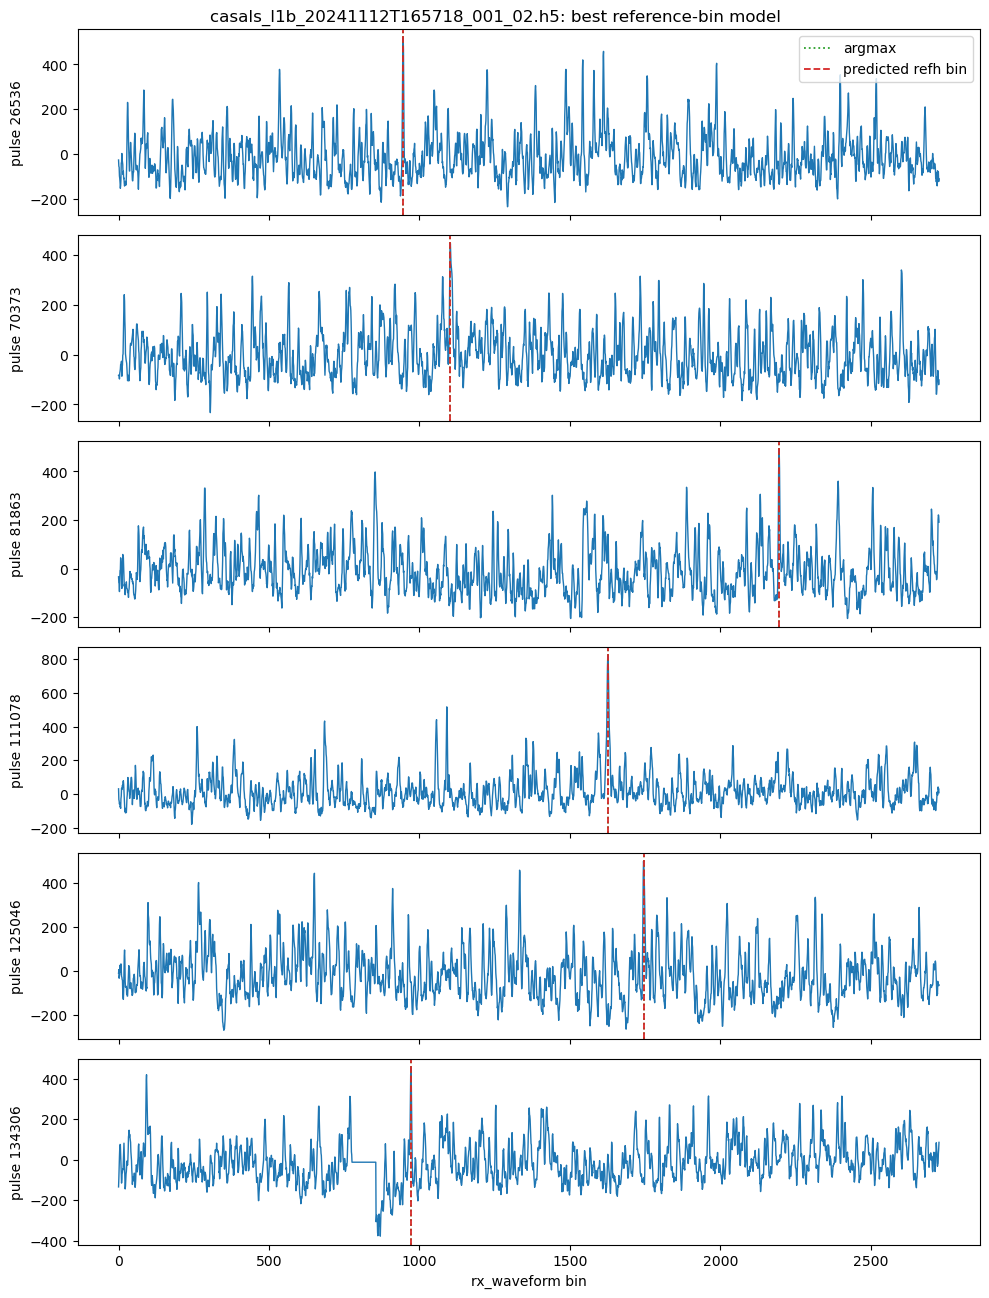

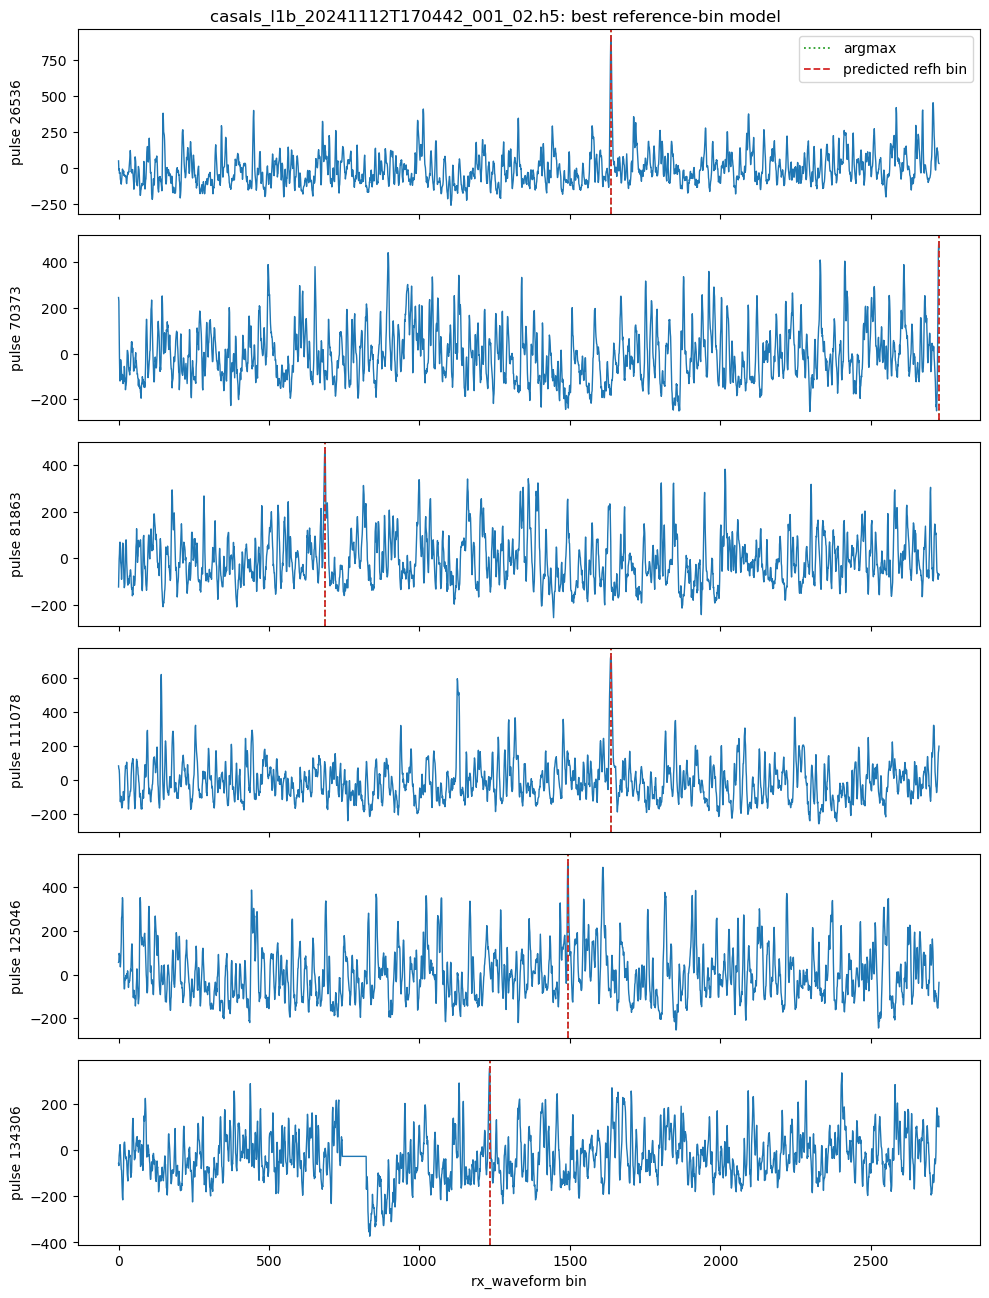

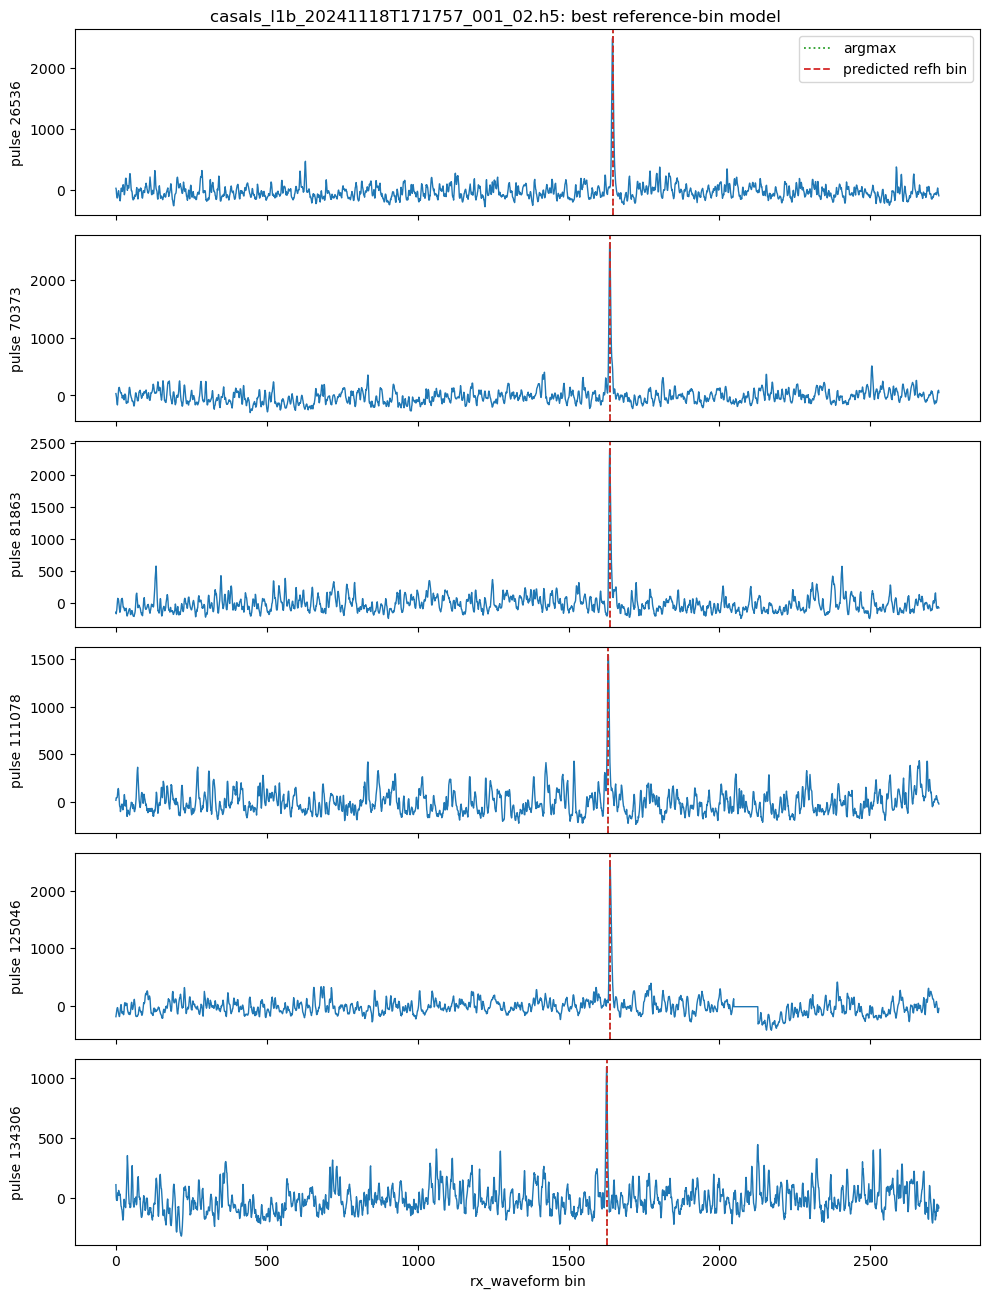

In [7]:
reference_plot_rows = []
reference_plot_cache = {}

for h5_path in h5_paths:
    h5_key = str(h5_path)
    with h5py.File(h5_path, "r") as f:
        rx_path = get_field_path(fields_df, h5_path, "rx_waveform", required=True)
        ref_path = get_field_path(fields_df, h5_path, "refh_bounce_time_offset", required=True)
        start_path = get_field_path(fields_df, h5_path, "rwstart_bounce_time_offset", required=True)
        stop_path = get_field_path(fields_df, h5_path, "rwstop_bounce_time_offset", required=True)
        bs_path = get_field_path(fields_df, h5_path, "bin_size", required=True)

        idx = sample_cache[h5_key]["idx"]
        rx = np.asarray(f[rx_path][idx, :], dtype=np.float32)
        ref = np.asarray(f[ref_path][idx], dtype=float)
        rwstart = np.asarray(f[start_path][idx], dtype=float)
        rwstop = np.asarray(f[stop_path][idx], dtype=float)
        bs = np.asarray(f[bs_path][idx], dtype=float)
        argmax_bins, strong_mask = make_strong_peak_mask(rx, strong_fraction=STRONG_PEAK_FRACTION)
        best_model_name = best_reference_model_df.loc[best_reference_model_df["h5_file"] == h5_key, "candidate_model"].iloc[0]
        pred = build_reference_model_predictions(ref, rwstart, rwstop, bs, rx.shape[1])[best_model_name]
        reference_plot_cache[h5_key] = {
            "idx": idx,
            "rx": rx,
            "argmax_bins": argmax_bins,
            "pred_bins": pred,
        }
        for local_i in range(min(N_WAVEFORM_PLOT_EXAMPLES, len(idx))):
            reference_plot_rows.append(
                {
                    "h5_file": h5_key,
                    "source_pulse_index": int(idx[local_i]),
                    "predicted_refh_bin": float(np.rint(pred[local_i])) if np.isfinite(pred[local_i]) else np.nan,
                    "argmax_bin": int(argmax_bins[local_i]),
                }
            )

reference_plot_df = pd.DataFrame(reference_plot_rows)
display(Markdown("### Sample reference-bin diagnostics"))
display(reference_plot_df)

for h5_file, cache in reference_plot_cache.items():
    n_plot = min(N_WAVEFORM_PLOT_EXAMPLES, cache["rx"].shape[0])
    fig, axes = plt.subplots(n_plot, 1, figsize=(10, 2.2 * n_plot), sharex=True)
    if n_plot == 1:
        axes = [axes]
    for i in range(n_plot):
        ax = axes[i]
        ax.plot(cache["rx"][i], linewidth=1.0)
        ax.axvline(cache["argmax_bins"][i], color="tab:green", linestyle=":", linewidth=1.3, label="argmax")
        if np.isfinite(cache["pred_bins"][i]):
            ax.axvline(int(np.rint(cache["pred_bins"][i])), color="tab:red", linestyle="--", linewidth=1.3, label="predicted refh bin")
        ax.set_ylabel(f"pulse {int(cache['idx'][i])}")
        if i == 0:
            ax.legend(loc="upper right")
    axes[-1].set_xlabel("rx_waveform bin")
    fig.suptitle(f"{Path(h5_file).name}: best reference-bin model")
    plt.tight_layout()
    plt.show()


## 5. Endpoint-segment closure

The H5 explicitly stores `rwstart_*`, `rwstop_*`, and `refh_*` geolocation. This section checks whether `refh` lies on the `rwstart -> rwstop` line segment, and whether the geometric segment parameter agrees with the timing fraction:

- `t_geom`: projection of `refh` onto the geodetic segment in ECEF
- `t_time`: `(refh_offset - rwstart_offset) / (rwstop_offset - rwstart_offset)`

This is the strongest H5-only internal-consistency test because it combines explicit endpoint geolocation with timing.


In [8]:
endpoint_rows = []
for h5_path in h5_paths:
    h5_key = str(h5_path)
    with h5py.File(h5_path, "r") as f:
        n_records = file_shape_df.loc[file_shape_df["h5_file"] == h5_key, "n_pulses"].iloc[0]
        n_take = min(int(n_records), int(MAX_PULSES_PER_H5) if MAX_PULSES_PER_H5 is not None else int(n_records))

        dist_pieces = []
        tdiff_pieces = []
        off_segment_count = 0
        total_count = 0

        for start_i in range(0, n_take, FULL_FILE_CHUNK_SIZE):
            stop_i = min(n_take, start_i + FULL_FILE_CHUNK_SIZE)
            rwstart_lon = np.asarray(f[get_field_path(fields_df, h5_path, "rwstart_longitude", required=True)][start_i:stop_i], dtype=float)
            rwstart_lat = np.asarray(f[get_field_path(fields_df, h5_path, "rwstart_latitude", required=True)][start_i:stop_i], dtype=float)
            rwstart_h = np.asarray(f[get_field_path(fields_df, h5_path, "rwstart", required=True)][start_i:stop_i], dtype=float)
            rwstop_lon = np.asarray(f[get_field_path(fields_df, h5_path, "rwstop_longitude", required=True)][start_i:stop_i], dtype=float)
            rwstop_lat = np.asarray(f[get_field_path(fields_df, h5_path, "rwstop_latitude", required=True)][start_i:stop_i], dtype=float)
            rwstop_h = np.asarray(f[get_field_path(fields_df, h5_path, "rwstop", required=True)][start_i:stop_i], dtype=float)
            refh_lon = np.asarray(f[get_field_path(fields_df, h5_path, "refh_longitude", required=True)][start_i:stop_i], dtype=float)
            refh_lat = np.asarray(f[get_field_path(fields_df, h5_path, "refh_latitude", required=True)][start_i:stop_i], dtype=float)
            refh_h = np.asarray(f[get_field_path(fields_df, h5_path, "refh", required=True)][start_i:stop_i], dtype=float)
            rwstart_offset = np.asarray(f[get_field_path(fields_df, h5_path, "rwstart_bounce_time_offset", required=True)][start_i:stop_i], dtype=float)
            rwstop_offset = np.asarray(f[get_field_path(fields_df, h5_path, "rwstop_bounce_time_offset", required=True)][start_i:stop_i], dtype=float)
            refh_offset = np.asarray(f[get_field_path(fields_df, h5_path, "refh_bounce_time_offset", required=True)][start_i:stop_i], dtype=float)

            p0 = geodetic_to_ecef(rwstart_lon, rwstart_lat, rwstart_h)
            p1 = geodetic_to_ecef(rwstop_lon, rwstop_lat, rwstop_h)
            pr = geodetic_to_ecef(refh_lon, refh_lat, refh_h)
            v = p1 - p0
            vv = np.sum(v * v, axis=1)
            t_geom = np.divide(np.sum((pr - p0) * v, axis=1), vv, out=np.full(len(vv), np.nan), where=vv > 0)
            t_time = np.divide(refh_offset - rwstart_offset, rwstop_offset - rwstart_offset, out=np.full(len(vv), np.nan), where=np.abs(rwstop_offset - rwstart_offset) > 0)
            proj = p0 + t_geom[:, None] * v
            dist = np.linalg.norm(pr - proj, axis=1).astype(np.float32)
            abs_t_diff = np.abs(t_geom - t_time).astype(np.float32)
            dist_pieces.append(dist)
            tdiff_pieces.append(abs_t_diff)
            off_segment_count += int(np.sum((t_geom < 0.0) | (t_geom > 1.0)))
            total_count += int(len(t_geom))

        dist_all = np.concatenate(dist_pieces) if dist_pieces else np.array([], dtype=np.float32)
        tdiff_all = np.concatenate(tdiff_pieces) if tdiff_pieces else np.array([], dtype=np.float32)
        frac_model_name = "((refh_offset - rwstart_offset) / (rwstop_offset - rwstart_offset)) * (n_rx_bins - 1)"
        frac_row = reference_bin_model_df[
            (reference_bin_model_df["h5_file"] == h5_key) &
            (reference_bin_model_df["candidate_model"] == frac_model_name)
        ].iloc[0]

        endpoint_rows.append(
            {
                "h5_file": h5_key,
                "median_refh_distance_to_rwstart_rwstop_segment_m": float(np.nanmedian(dist_all)) if len(dist_all) else np.nan,
                "p90_refh_distance_to_rwstart_rwstop_segment_m": float(np.nanpercentile(dist_all, 90)) if len(dist_all) else np.nan,
                "median_abs_t_geom_minus_t_time": float(np.nanmedian(tdiff_all)) if len(tdiff_all) else np.nan,
                "p90_abs_t_geom_minus_t_time": float(np.nanpercentile(tdiff_all, 90)) if len(tdiff_all) else np.nan,
                "off_segment_fraction": off_segment_count / total_count if total_count else np.nan,
                "t_time_bin_model": frac_model_name,
                "t_time_bin_model_median_abs_diff_to_nearest_strong_peak": float(frac_row["median_abs_bin_diff_to_nearest_strong_peak"]),
                "t_time_bin_model_p90_abs_diff_to_nearest_strong_peak": float(frac_row["p90_abs_bin_diff_to_nearest_strong_peak"]),
            }
        )

endpoint_segment_closure_df = pd.DataFrame(endpoint_rows)
endpoint_segment_closure_df["endpoint_segment_closure_quality"] = endpoint_segment_closure_df.apply(
    lambda row: classify_endpoint_quality(
        row["median_refh_distance_to_rwstart_rwstop_segment_m"],
        row["median_abs_t_geom_minus_t_time"],
        row["t_time_bin_model_median_abs_diff_to_nearest_strong_peak"],
        row["t_time_bin_model_p90_abs_diff_to_nearest_strong_peak"],
    ),
    axis=1,
)
display(endpoint_segment_closure_df)


,h5_file,median_refh_distance_to_rwstart_rwstop_segment_m,p90_refh_distance_to_rwstart_rwstop_segment_m,median_abs_t_geom_minus_t_time,p90_abs_t_geom_minus_t_time,off_segment_fraction,t_time_bin_model,t_time_bin_model_median_abs_diff_to_nearest_strong_peak,t_time_bin_model_p90_abs_diff_to_nearest_strong_peak,endpoint_segment_closure_quality
0,C:\Users\zhong267\OneDrive - purdue.edu\Research\CASALS\CASALS_L1B\casals_h5_downloads\casals_l1b_20241112T165718_001_02.h5,0.000004,0.000011,0.000001,0.000001,0.0,((refh_offset - rwstart_offset) / (rwstop_offset - rwstart_offset)) * (n_rx_bins - 1),0.0,0.0,strong_endpoint_segment_closure
1,C:\Users\zhong267\OneDrive - purdue.edu\Research\CASALS\CASALS_L1B\casals_h5_downloads\casals_l1b_20241112T170442_001_02.h5,0.000005,0.000010,0.000001,0.000001,0.0,((refh_offset - rwstart_offset) / (rwstop_offset - rwstart_offset)) * (n_rx_bins - 1),0.0,0.0,strong_endpoint_segment_closure
2,C:\Users\zhong267\OneDrive - purdue.edu\Research\CASALS\CASALS_L1B\casals_h5_downloads\casals_l1b_20241118T171757_001_02.h5,0.000004,0.000011,0.000001,0.000001,0.0,((refh_offset - rwstart_offset) / (rwstop_offset - rwstart_offset)) * (n_rx_bins - 1),0.0,0.0,strong_endpoint_segment_closure


## 6. Derived peak geolocation by two paths

Once closure is established, the notebook generates candidate coordinates for a deterministic subset of pulses:

- **Primary path**: interpolate along the explicit `rwstart -> rwstop` segment using `t_peak = peak_bin / (n_rx_bins - 1)`.
- **Secondary path**: propagate from `refh` using beam direction plus the empirically selected range-spacing interpretation.

The beam-path sign is selected by comparing beam-derived coordinates against segment-interpolated coordinates and keeping the lower-disagreement convention.


In [9]:
derived_base_rows = []

for h5_path in h5_paths:
    h5_key = str(h5_path)
    with h5py.File(h5_path, "r") as f:
        rx_path = get_field_path(fields_df, h5_path, "rx_waveform", required=True)
        refh_offset_path = get_field_path(fields_df, h5_path, "refh_bounce_time_offset", required=True)
        rwstart_offset_path = get_field_path(fields_df, h5_path, "rwstart_bounce_time_offset", required=True)
        rwstop_offset_path = get_field_path(fields_df, h5_path, "rwstop_bounce_time_offset", required=True)
        bs_path = get_field_path(fields_df, h5_path, "bin_size", required=True)
        n_records, n_bins = f[rx_path].shape
        idx = sample_indices(n_records, n_sample=N_DERIVED_PEAK_EXAMPLES, seed=RANDOM_SEED + 100)

        rx = np.asarray(f[rx_path][idx, :], dtype=np.float32)
        refh_offset = np.asarray(f[refh_offset_path][idx], dtype=float)
        rwstart_offset = np.asarray(f[rwstart_offset_path][idx], dtype=float)
        rwstop_offset = np.asarray(f[rwstop_offset_path][idx], dtype=float)
        bs = np.asarray(f[bs_path][idx], dtype=float)
        ref_bin_pred = build_reference_model_predictions(
            refh_offset,
            rwstart_offset,
            rwstop_offset,
            bs,
            n_bins,
        )[best_reference_model_df.loc[best_reference_model_df["h5_file"] == h5_key, "candidate_model"].iloc[0]]

        ref_lon = np.asarray(f[get_field_path(fields_df, h5_path, "refh_longitude", required=True)][idx], dtype=float)
        ref_lat = np.asarray(f[get_field_path(fields_df, h5_path, "refh_latitude", required=True)][idx], dtype=float)
        ref_h = np.asarray(f[get_field_path(fields_df, h5_path, "refh", required=True)][idx], dtype=float)
        rwstart_lon = np.asarray(f[get_field_path(fields_df, h5_path, "rwstart_longitude", required=True)][idx], dtype=float)
        rwstart_lat = np.asarray(f[get_field_path(fields_df, h5_path, "rwstart_latitude", required=True)][idx], dtype=float)
        rwstart_h = np.asarray(f[get_field_path(fields_df, h5_path, "rwstart", required=True)][idx], dtype=float)
        rwstop_lon = np.asarray(f[get_field_path(fields_df, h5_path, "rwstop_longitude", required=True)][idx], dtype=float)
        rwstop_lat = np.asarray(f[get_field_path(fields_df, h5_path, "rwstop_latitude", required=True)][idx], dtype=float)
        rwstop_h = np.asarray(f[get_field_path(fields_df, h5_path, "rwstop", required=True)][idx], dtype=float)
        az = np.asarray(f[get_field_path(fields_df, h5_path, "local_beam_azimuth", required=True)][idx], dtype=float)
        el = np.asarray(f[get_field_path(fields_df, h5_path, "local_beam_elevation", required=True)][idx], dtype=float)

        sweep_path = get_field_path(fields_df, h5_path, "sweep_num", required=False)
        track_path = get_field_path(fields_df, h5_path, "track_num", required=False)
        snr_path = get_field_path(fields_df, h5_path, "refh_snr", required=False)
        sweep = np.asarray(f[sweep_path][idx], dtype=float) if sweep_path else np.full(len(idx), np.nan)
        track = np.asarray(f[track_path][idx], dtype=float) if track_path else np.full(len(idx), np.nan)
        snr = np.asarray(f[snr_path][idx], dtype=float) if snr_path else np.full(len(idx), np.nan)

        for local_i, pulse_index in enumerate(idx):
            peaks, strengths = safe_find_peaks_1d(rx[local_i], top_k=TOP_PEAKS_PER_WAVEFORM)
            if peaks.size == 0:
                continue
            for rank, (peak_bin, peak_amp) in enumerate(zip(peaks, strengths), start=1):
                t_peak = peak_bin / (n_bins - 1)
                segment = interpolate_segment_geodetic(
                    np.array([rwstart_lon[local_i]]),
                    np.array([rwstart_lat[local_i]]),
                    np.array([rwstart_h[local_i]]),
                    np.array([rwstop_lon[local_i]]),
                    np.array([rwstop_lat[local_i]]),
                    np.array([rwstop_h[local_i]]),
                    np.array([t_peak]),
                )
                derived_base_rows.append(
                    {
                        "h5_file": h5_key,
                        "source_pulse_index": int(pulse_index),
                        "peak_rank_by_amplitude": int(rank),
                        "peak_bin": int(peak_bin),
                        "peak_amp": float(peak_amp),
                        "predicted_refh_bin": float(ref_bin_pred[local_i]) if np.isfinite(ref_bin_pred[local_i]) else np.nan,
                        "t_peak": float(t_peak),
                        "ref_lon": float(ref_lon[local_i]),
                        "ref_lat": float(ref_lat[local_i]),
                        "ref_h": float(ref_h[local_i]),
                        "rwstart_lon": float(rwstart_lon[local_i]),
                        "rwstart_lat": float(rwstart_lat[local_i]),
                        "rwstart_h": float(rwstart_h[local_i]),
                        "rwstop_lon": float(rwstop_lon[local_i]),
                        "rwstop_lat": float(rwstop_lat[local_i]),
                        "rwstop_h": float(rwstop_h[local_i]),
                        "local_beam_azimuth": float(az[local_i]),
                        "local_beam_elevation": float(el[local_i]),
                        "bin_size": float(bs[local_i]),
                        "refh_snr": float(snr[local_i]) if np.isfinite(snr[local_i]) else np.nan,
                        "sweep_num": int(sweep[local_i]) if np.isfinite(sweep[local_i]) else np.nan,
                        "track_num": int(track[local_i]) if np.isfinite(track[local_i]) else np.nan,
                        "segment_lon": float(segment["segment_lon"][0]),
                        "segment_lat": float(segment["segment_lat"][0]),
                        "segment_h": float(segment["segment_h"][0]),
                        "segment_ecef_x": float(segment["segment_ecef"][0, 0]),
                        "segment_ecef_y": float(segment["segment_ecef"][0, 1]),
                        "segment_ecef_z": float(segment["segment_ecef"][0, 2]),
                    }
                )

derived_base_df = pd.DataFrame(derived_base_rows)
display(Markdown("### Derived-peak base rows"))
display(derived_base_df.head(50))
print(f"Derived base rows: {len(derived_base_df)}")

beam_agreement_rows = []
beam_candidate_rows = []

for h5_file, g in derived_base_df.groupby("h5_file"):
    angle_unit = angle_unit_choice[h5_file]
    spacing_choice = range_spacing_choice[h5_file]
    for vector_direction in ["ref_to_sensor", "sensor_to_ref"]:
        beam = propagate_from_refh_with_beam(
            g["ref_lon"].to_numpy(),
            g["ref_lat"].to_numpy(),
            g["ref_h"].to_numpy(),
            g["local_beam_azimuth"].to_numpy(),
            g["local_beam_elevation"].to_numpy(),
            g["predicted_refh_bin"].to_numpy(),
            g["peak_bin"].to_numpy(),
            g["bin_size"].to_numpy(),
            angle_unit=angle_unit,
            range_spacing_interpretation=spacing_choice,
            vector_direction=vector_direction,
        )
        segment_xyz = g[["segment_ecef_x", "segment_ecef_y", "segment_ecef_z"]].to_numpy()
        disagreement = rms_distance_m(beam["beam_ecef"], segment_xyz)
        beam_agreement_rows.append(
            {
                "h5_file": h5_file,
                "angle_unit_selected": angle_unit,
                "range_spacing_interpretation": spacing_choice,
                "beam_vector_direction": vector_direction,
                "n_rows": int(len(g)),
                "median_beam_vs_segment_disagreement_m": float(np.nanmedian(disagreement)) if len(disagreement) else np.nan,
                "p90_beam_vs_segment_disagreement_m": float(np.nanpercentile(disagreement, 90)) if len(disagreement) else np.nan,
            }
        )
        tmp = g.copy()
        tmp["angle_unit_selected"] = angle_unit
        tmp["range_spacing_interpretation"] = spacing_choice
        tmp["beam_vector_direction"] = vector_direction
        tmp["beam_lon"] = beam["beam_lon"]
        tmp["beam_lat"] = beam["beam_lat"]
        tmp["beam_h"] = beam["beam_h"]
        tmp["beam_ecef_x"] = beam["beam_ecef"][:, 0]
        tmp["beam_ecef_y"] = beam["beam_ecef"][:, 1]
        tmp["beam_ecef_z"] = beam["beam_ecef"][:, 2]
        tmp["delta_range_m"] = beam["delta_range_m"]
        tmp["spacing_m_per_bin"] = beam["spacing_m_per_bin"]
        tmp["beam_vs_segment_disagreement_m"] = disagreement
        beam_candidate_rows.append(tmp)

beam_model_agreement_df = pd.DataFrame(beam_agreement_rows)
beam_model_agreement_df["beam_model_agreement_quality"] = beam_model_agreement_df.apply(
    lambda row: classify_beam_agreement(
        row["median_beam_vs_segment_disagreement_m"],
        row["p90_beam_vs_segment_disagreement_m"],
    ),
    axis=1,
)

best_beam_rows = []
for h5_file, g in beam_model_agreement_df.groupby("h5_file"):
    best = g.sort_values(
        ["median_beam_vs_segment_disagreement_m", "p90_beam_vs_segment_disagreement_m"],
        ascending=[True, True],
    ).iloc[0].copy()
    best_beam_rows.append(best)
best_beam_config_df = pd.DataFrame(best_beam_rows)

beam_candidate_df = pd.concat(beam_candidate_rows, ignore_index=True) if beam_candidate_rows else pd.DataFrame()
if len(beam_candidate_df):
    derived_peak_candidates_df = beam_candidate_df.merge(
        best_beam_config_df[["h5_file", "beam_vector_direction"]],
        on=["h5_file", "beam_vector_direction"],
        how="inner",
    ).copy()
    derived_peak_candidates_df["method_disagreement_m"] = derived_peak_candidates_df["beam_vs_segment_disagreement_m"]
else:
    derived_peak_candidates_df = pd.DataFrame()

display(Markdown("### Beam-model agreement summary"))
display(beam_model_agreement_df.sort_values(["h5_file", "median_beam_vs_segment_disagreement_m"]).reset_index(drop=True))
display(Markdown("### Selected beam configuration"))
display(best_beam_config_df.reset_index(drop=True))
display(Markdown("### Derived peak candidates with both paths"))
display(derived_peak_candidates_df.head(50))


### Derived-peak base rows

,h5_file,source_pulse_index,peak_rank_by_amplitude,peak_bin,peak_amp,predicted_refh_bin,t_peak,ref_lon,ref_lat,ref_h,rwstart_lon,rwstart_lat,rwstart_h,rwstop_lon,rwstop_lat,rwstop_h,local_beam_azimuth,local_beam_elevation,bin_size,refh_snr,sweep_num,track_num,segment_lon,segment_lat,segment_h,segment_ecef_x,segment_ecef_y,segment_ecef_z
0,C:\Users\zhong267\OneDrive - purdue.edu\Research\CASALS\CASALS_L1B\casals_h5_downloads\casals_l1b_20241112T165718_001_02.h5,56726,1,2491,385.0,5.497984,0.913458,-75.280397,38.403713,219.357456,-75.280398,38.403713,220.178930,-75.280099,38.403899,-187.269864,-2.238691,1.489358,0.149358,1.610678,221,180,-75.280125,38.403882,-152.008443,1.271632e+06,-4.840333e+06,3.940579e+06
1,C:\Users\zhong267\OneDrive - purdue.edu\Research\CASALS\CASALS_L1B\casals_h5_downloads\casals_l1b_20241112T165718_001_02.h5,56726,2,58,310.0,5.497984,0.021269,-75.280397,38.403713,219.357456,-75.280398,38.403713,220.178930,-75.280099,38.403899,-187.269864,-2.238691,1.489358,0.149358,1.610678,221,180,-75.280391,38.403717,211.512984,1.271685e+06,-4.840625e+06,3.940791e+06
2,C:\Users\zhong267\OneDrive - purdue.edu\Research\CASALS\CASALS_L1B\casals_h5_downloads\casals_l1b_20241112T165718_001_02.h5,56726,3,1470,308.0,5.497984,0.539054,-75.280397,38.403713,219.357456,-75.280398,38.403713,220.178930,-75.280099,38.403899,-187.269864,-2.238691,1.489358,0.149358,1.610678,221,180,-75.280237,38.403813,0.542045,1.271655e+06,-4.840456e+06,3.940668e+06
3,C:\Users\zhong267\OneDrive - purdue.edu\Research\CASALS\CASALS_L1B\casals_h5_downloads\casals_l1b_20241112T165718_001_02.h5,56726,4,2242,306.0,5.497984,0.822149,-75.280397,38.403713,219.357456,-75.280398,38.403713,220.178930,-75.280099,38.403899,-187.269864,-2.238691,1.489358,0.149358,1.610678,221,180,-75.280152,38.403866,-114.804653,1.271638e+06,-4.840363e+06,3.940601e+06
4,C:\Users\zhong267\OneDrive - purdue.edu\Research\CASALS\CASALS_L1B\casals_h5_downloads\casals_l1b_20241112T165718_001_02.h5,56726,5,441,300.0,5.497984,0.161716,-75.280397,38.403713,219.357456,-75.280398,38.403713,220.178930,-75.280099,38.403899,-187.269864,-2.238691,1.489358,0.149358,1.610678,221,180,-75.280349,38.403743,154.287859,1.271677e+06,-4.840579e+06,3.940757e+06
5,C:\Users\zhong267\OneDrive - purdue.edu\Research\CASALS\CASALS_L1B\casals_h5_downloads\casals_l1b_20241112T165718_001_02.h5,56726,6,1079,288.0,5.497984,0.395673,-75.280397,38.403713,219.357456,-75.280398,38.403713,220.178930,-75.280099,38.403899,-187.269864,-2.238691,1.489358,0.149358,1.610678,221,180,-75.280280,38.403786,58.962463,1.271663e+06,-4.840503e+06,3.940702e+06
6,C:\Users\zhong267\OneDrive - purdue.edu\Research\CASALS\CASALS_L1B\casals_h5_downloads\casals_l1b_20241112T165718_001_02.h5,71094,1,2661,477.0,2660.524377,0.975798,-75.280139,38.403936,-177.880678,-75.280429,38.403757,219.658313,-75.280132,38.403940,-187.813495,-2.235869,1.490053,0.149366,1.650323,277,181,-75.280139,38.403936,-177.951693,1.271625e+06,-4.840310e+06,3.940568e+06
7,C:\Users\zhong267\OneDrive - purdue.edu\Research\CASALS\CASALS_L1B\casals_h5_downloads\casals_l1b_20241112T165718_001_02.h5,71094,2,2521,473.0,2660.524377,0.924459,-75.280139,38.403936,-177.880678,-75.280429,38.403757,219.658313,-75.280132,38.403940,-187.813495,-2.235869,1.490053,0.149366,1.650323,277,181,-75.280154,38.403926,-157.032719,1.271628e+06,-4.840327e+06,3.940580e+06
8,C:\Users\zhong267\OneDrive - purdue.edu\Research\CASALS\CASALS_L1B\casals_h5_downloads\casals_l1b_20241112T165718_001_02.h5,71094,3,1634,467.0,2660.524377,0.599193,-75.280139,38.403936,-177.880678,-75.280429,38.403757,219.658313,-75.280132,38.403940,-187.813495,-2.235869,1.490053,0.149366,1.650323,277,181,-75.280251,38.403867,-24.496066,1.271647e+06,-4.840433e+06,3.940657e+06
9,C:\Users\zhong267\OneDrive - purdue.edu\Research\CASALS\CASALS_L1B\casals_h5_downloads\casals_l1b_20241112T165718_001_02.h5,71094,4,2203,458.0,2660.524377,0.807847,-75.280139,38.403936,-177.880678,-75.280429,38.403757,219.658313,-75.280132,38.403940,-187.8

Derived base rows: 981


### Beam-model agreement summary

,h5_file,angle_unit_selected,range_spacing_interpretation,beam_vector_direction,n_rows,median_beam_vs_segment_disagreement_m,p90_beam_vs_segment_disagreement_m,beam_model_agreement_quality
0,C:\Users\zhong267\OneDrive - purdue.edu\Research\CASALS\CASALS_L1B\casals_h5_downloads\casals_l1b_20241112T165718_001_02.h5,radian,bin_size_as_seconds_times_c,sensor_to_ref,331,2.718026e+10,7.199293e+10,weak_beam_agreement
1,C:\Users\zhong267\OneDrive - purdue.edu\Research\CASALS\CASALS_L1B\casals_h5_downloads\casals_l1b_20241112T165718_001_02.h5,radian,bin_size_as_seconds_times_c,ref_to_sensor,331,2.718026e+10,7.199293e+10,weak_beam_agreement
2,C:\Users\zhong267\OneDrive - purdue.edu\Research\CASALS\CASALS_L1B\casals_h5_downloads\casals_l1b_20241112T170442_001_02.h5,radian,bin_size_as_seconds_times_c,sensor_to_ref,326,2.605089e+10,6.704921e+10,weak_beam_agreement
3,C:\Users\zhong267\OneDrive - purdue.edu\Research\CASALS\CASALS_L1B\casals_h5_downloads\casals_l1b_20241112T170442_001_02.h5,radian,bin_size_as_seconds_times_c,ref_to_sensor,326,2.605089e+10,6.704921e+10,weak_beam_agreement
4,C:\Users\zhong267\OneDrive - purdue.edu\Research\CASALS\CASALS_L1B\casals_h5_downloads\casals_l1b_20241118T171757_001_02.h5,radian,bin_size_as_seconds_times_c,sensor_to_ref,324,2.399808e+10,6.028206e+10,weak_beam_agreement
5,C:\Users\zhong267\OneDrive - purdue.edu\Research\CASALS\CASALS_L1B\casals_h5_downloads\casals_l1b_20241118T171757_001_02.h5,radian,bin_size_as_seconds_times_c,ref_to_sensor,324,2.399808e+10,6.028206e+10,weak_beam_agreement


### Selected beam configuration

,h5_file,angle_unit_selected,range_spacing_interpretation,beam_vector_direction,n_rows,median_beam_vs_segment_disagreement_m,p90_beam_vs_segment_disagreement_m,beam_model_agreement_quality
0,C:\Users\zhong267\OneDrive - purdue.edu\Research\CASALS\CASALS_L1B\casals_h5_downloads\casals_l1b_20241112T165718_001_02.h5,radian,bin_size_as_seconds_times_c,sensor_to_ref,331,2.718026e+10,7.199293e+10,weak_beam_agreement
1,C:\Users\zhong267\OneDrive - purdue.edu\Research\CASALS\CASALS_L1B\casals_h5_downloads\casals_l1b_20241112T170442_001_02.h5,radian,bin_size_as_seconds_times_c,sensor_to_ref,326,2.605089e+10,6.704921e+10,weak_beam_agreement
2,C:\Users\zhong267\OneDrive - purdue.edu\Research\CASALS\CASALS_L1B\casals_h5_downloads\casals_l1b_20241118T171757_001_02.h5,radian,bin_size_as_seconds_times_c,sensor_to_ref,324,2.399808e+10,6.028206e+10,weak_beam_agreement


### Derived peak candidates with both paths

,h5_file,source_pulse_index,peak_rank_by_amplitude,peak_bin,peak_amp,predicted_refh_bin,t_peak,ref_lon,ref_lat,ref_h,rwstart_lon,rwstart_lat,rwstart_h,rwstop_lon,rwstop_lat,rwstop_h,local_beam_azimuth,local_beam_elevation,bin_size,refh_snr,sweep_num,track_num,segment_lon,segment_lat,segment_h,segment_ecef_x,segment_ecef_y,segment_ecef_z,angle_unit_selected,range_spacing_interpretation,beam_vector_direction,beam_lon,beam_lat,beam_h,beam_ecef_x,beam_ecef_y,beam_ecef_z,delta_range_m,spacing_m_per_bin,beam_vs_segment_disagreement_m,method_disagreement_m
0,C:\Users\zhong267\OneDrive - purdue.edu\Research\CASALS\CASALS_L1B\casals_h5_downloads\casals_l1b_20241112T165718_001_02.h5,56726,1,2491,385.0,5.497984,0.913458,-75.280397,38.403713,219.357456,-75.280398,38.403713,220.178930,-75.280099,38.403899,-187.269864,-2.238691,1.489358,0.149358,1.610678,221,180,-75.280125,38.403882,-152.008443,1.271632e+06,-4.840333e+06,3.940579e+06,radian,bin_size_as_seconds_times_c,sensor_to_ref,100.223887,-35.426322,1.112792e+11,-1.609566e+10,8.924244e+10,-6.450727e+10,1.112919e+11,4.477642e+07,1.112919e+11,1.112919e+11
1,C:\Users\zhong267\OneDrive - purdue.edu\Research\CASALS\CASALS_L1B\casals_h5_downloads\casals_l1b_20241112T165718_001_02.h5,56726,2,58,310.0,5.497984,0.021269,-75.280397,38.403713,219.357456,-75.280398,38.403713,220.178930,-75.280099,38.403899,-187.269864,-2.238691,1.489358,0.149358,1.610678,221,180,-75.280391,38.403717,211.512984,1.271685e+06,-4.840625e+06,3.940791e+06,radian,bin_size_as_seconds_times_c,sensor_to_ref,100.212371,-35.419173,2.338131e+09,-3.387487e+08,1.880357e+09,-1.358749e+09,2.350852e+09,4.477642e+07,2.350852e+09,2.350852e+09
2,C:\Users\zhong267\OneDrive - purdue.edu\Research\CASALS\CASALS_L1B\casals_h5_downloads\casals_l1b_20241112T165718_001_02.h5,56726,3,1470,308.0,5.497984,0.539054,-75.280397,38.403713,219.357456,-75.280398,38.403713,220.178930,-75.280099,38.403899,-187.269864,-2.238691,1.489358,0.149358,1.610678,221,180,-75.280237,38.403813,0.542045,1.271655e+06,-4.840456e+06,3.940668e+06,radian,bin_size_as_seconds_times_c,sensor_to_ref,100.223714,-35.426215,6.556244e+10,-9.483328e+09,5.258124e+10,-3.800721e+10,6.557516e+10,4.477642e+07,6.557516e+10,6.557516e+10
3,C:\Users\zhong267\OneDrive - purdue.edu\Research\CASALS\CASALS_L1B\casals_h5_downloads\casals_l1b_20241112T165718_001_02.h5,56726,4,2242,306.0,5.497984,0.822149,-75.280397,38.403713,219.357456,-75.280398,38.403713,220.178930,-75.280099,38.403899,-187.269864,-2.238691,1.489358,0.149358,1.610678,221,180,-75.280152,38.403866,-114.804653,1.271638e+06,-4.840363e+06,3.940601e+06,radian,bin_size_as_seconds_times_c,sensor_to_ref,100.223859,-35.426305,1.001298e+11,-1.448305e+10,8.030156e+10,-5.804447e+10,1.001426e+11,4.477642e+07,1.001426e+11,1.001426e+11
4,C:\Users\zhong267\OneDrive - purdue.edu\Research\CASALS\CASALS_L1B\casals_h5_downloads\casals_l1b_20241112T165718_001_02.h5,56726,5,441,300.0,5.497984,0.161716,-75.280397,38.403713,219.357456,-75.280398,38.403713,220.178930,-75.280099,38.403899,-187.269864,-2.238691,1.489358,0.149358,1.610678,221,180,-75.280349,38.403743,154.287859,1.271677e+06,-4.840579e+06,3.940757e+06,radian,bin_size_as_seconds_times_c,sensor_to_ref,100.222719,-35.425598,1.948750e+10,-2.819183e+09,1.563279e+10,-1.129951e+10,1.950022e+10,4.477642e+07,1.950022e+10,1.950022e+10
5,C:\Users\zhong267\OneDrive - purdue.edu\Research\CASALS\CASALS_L1B\casals_h5_downloads\casals_l1b_20241112T165718_001_02.h5,56726,6,1079,288.0,5.497984,0.395673,-75.280397,38.403713,219.357456,-75.280398,38.403713,220.178930,-75.280099,38.403899,-187.269864,-2.238691,1.489358,0.149358,1.610678,221,180,-75.280280,38.403786,58.962463,1.271663e+06,-4.840503e+06,3.940702e+06,radian,bin_size_as_seconds_times_c,sensor_to_ref,100.223561,-35.426120,4.805486e+10,-6.951082e+09,3.854155e+10,-2.785880e+10,4.806758e+10,4.477642e+07,4.806758e+10,4.806758e+10
6,C:\Users\zhong267\OneDrive - purdue.edu\Research\CASALS\CASALS_L1B\casals_h5_downloads\casals_l1b_20241112T165718_001_02.h

### Derived peak summary

,h5_file,n_rows,median_abs_delta_range_m,p95_abs_delta_range_m,median_method_disagreement_m,p90_method_disagreement_m
0,C:\Users\zhong267\OneDrive - purdue.edu\Research\CASALS\CASALS_L1B\casals_h5_downloads\casals_l1b_20241112T165718_001_02.h5,331,2.718026e+10,8.887478e+10,2.718026e+10,7.199293e+10
1,C:\Users\zhong267\OneDrive - purdue.edu\Research\CASALS\CASALS_L1B\casals_h5_downloads\casals_l1b_20241112T170442_001_02.h5,326,2.605089e+10,7.796258e+10,2.605089e+10,6.704921e+10
2,C:\Users\zhong267\OneDrive - purdue.edu\Research\CASALS\CASALS_L1B\casals_h5_downloads\casals_l1b_20241118T171757_001_02.h5,324,2.399808e+10,6.725857e+10,2.399808e+10,6.028206e+10


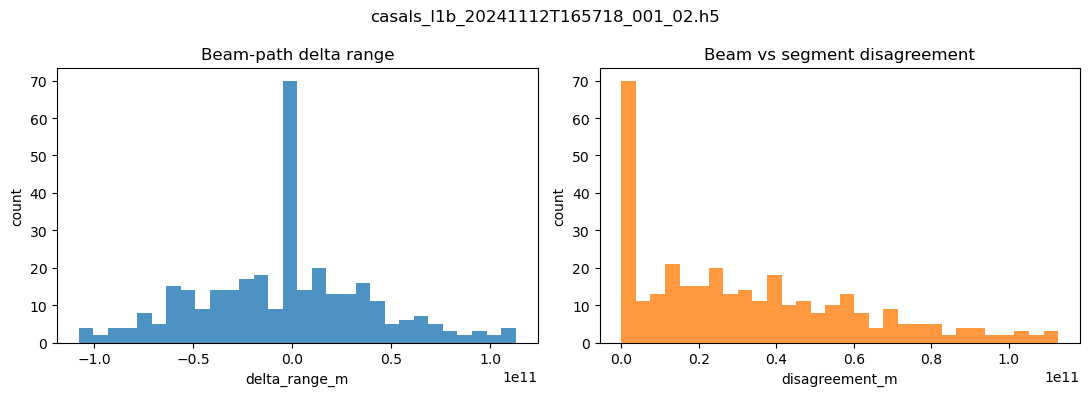

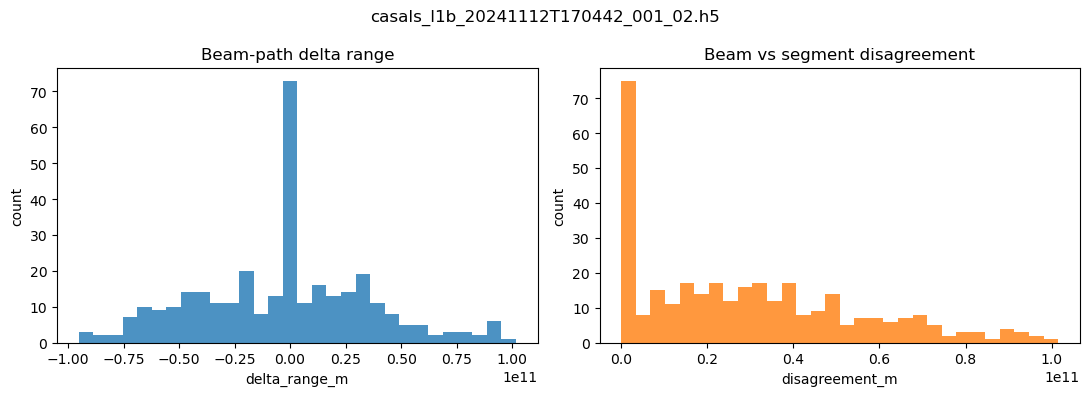

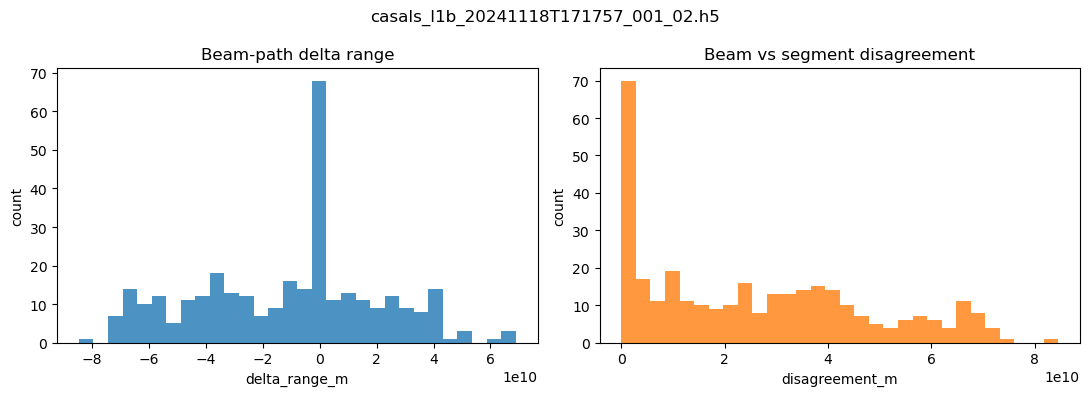

In [10]:
if len(derived_peak_candidates_df):
    derived_peak_summary_df = (
        derived_peak_candidates_df.groupby("h5_file")
        .agg(
            n_rows=("peak_bin", "size"),
            median_abs_delta_range_m=("delta_range_m", lambda x: float(np.nanmedian(np.abs(x)))),
            p95_abs_delta_range_m=("delta_range_m", lambda x: float(np.nanpercentile(np.abs(x), 95))),
            median_method_disagreement_m=("method_disagreement_m", lambda x: float(np.nanmedian(x))),
            p90_method_disagreement_m=("method_disagreement_m", lambda x: float(np.nanpercentile(x, 90))),
        )
        .reset_index()
    )
    display(Markdown("### Derived peak summary"))
    display(derived_peak_summary_df)

    for h5_file, g in derived_peak_candidates_df.groupby("h5_file"):
        fig, axes = plt.subplots(1, 2, figsize=(11, 4))
        axes[0].hist(g["delta_range_m"].to_numpy(), bins=30, color="tab:blue", alpha=0.8)
        axes[0].set_title("Beam-path delta range")
        axes[0].set_xlabel("delta_range_m")
        axes[0].set_ylabel("count")

        axes[1].hist(g["method_disagreement_m"].to_numpy(), bins=30, color="tab:orange", alpha=0.8)
        axes[1].set_title("Beam vs segment disagreement")
        axes[1].set_xlabel("disagreement_m")
        axes[1].set_ylabel("count")
        fig.suptitle(Path(h5_file).name)
        plt.tight_layout()
        plt.show()
else:
    derived_peak_summary_df = pd.DataFrame()


## 7. Final decision schema

The final decision is graded, not binary. Each H5 gets:

- `status`
- `stored_geolocation_summary`
- `derived_geolocation_summary`
- `scientific_usability`
- `best_reference_bin_model`
- `angle_unit_selected`
- `range_spacing_interpretation`
- `endpoint_segment_closure_quality`
- `beam_model_agreement_quality`
- `notes_on_conflicts`


In [11]:
decision_rows = []

for h5_path in h5_paths:
    h5_key = str(h5_path)
    best_ref = best_reference_model_df[best_reference_model_df["h5_file"] == h5_key].iloc[0]
    endpoint = endpoint_segment_closure_df[endpoint_segment_closure_df["h5_file"] == h5_key].iloc[0]
    spacing = range_spacing_choice_df[range_spacing_choice_df["h5_file"] == h5_key].iloc[0]
    best_beam = best_beam_config_df[best_beam_config_df["h5_file"] == h5_key].iloc[0] if len(best_beam_config_df) else None
    explicit_multi = explicit_multi_geo_df[explicit_multi_geo_df["h5_file"] == h5_key] if len(explicit_multi_geo_df) else pd.DataFrame()

    notes = []
    root_attrs_here = root_attr_df[root_attr_df["h5_file"] == h5_key]
    sec_to_meters_rows = root_attrs_here[root_attrs_here["attr_name"] == "sec_to_meters"]
    if len(sec_to_meters_rows) and spacing["range_spacing_interpretation"] == "bin_size_as_seconds_times_c":
        notes.append("Root attrs include sec_to_meters = c/2, but whole-window closure empirically supports bin_size * c.")

    stored_summary = (
        "H5 stores explicit per-pulse geolocation for refh, rwstart, rwstop, and instrument position, "
        "but no explicit non-reference peak / return / per-bin lon-lat-height arrays were found."
        if len(explicit_multi) == 0
        else "Coordinate-like return/peak/bin arrays were found and should be inspected as explicit stored non-reference geolocation candidates."
    )

    if len(explicit_multi):
        status = "EXPLICIT_MULTI_RETURN_OR_PER_BIN_GEOLOCATION_FOUND"
        derived_summary = "Derived reconstruction is unnecessary as a first choice because explicit candidate non-reference geolocation arrays exist in the H5."
        scientific_usability = "Prefer inspection of the stored coordinate structures before deriving any experimental waveform-peak point cloud."
    else:
        strong_ref = (
            best_ref["valid_fraction"] >= 0.999
            and best_ref["median_abs_bin_diff_to_nearest_strong_peak"] <= 1
            and best_ref["p90_abs_bin_diff_to_nearest_strong_peak"] <= 3
        )
        moderate_ref = (
            best_ref["valid_fraction"] >= 0.99
            and best_ref["median_abs_bin_diff_to_nearest_strong_peak"] <= 5
            and best_ref["p90_abs_bin_diff_to_nearest_strong_peak"] <= 25
        )
        strong_endpoint = (
            endpoint["median_refh_distance_to_rwstart_rwstop_segment_m"] <= 0.01
            and endpoint["median_abs_t_geom_minus_t_time"] <= 1e-4
        )
        moderate_endpoint = (
            endpoint["median_refh_distance_to_rwstart_rwstart_rwstop_segment_m"] <= 0.1
            if "median_refh_distance_to_rwstart_rwstart_rwstop_segment_m" in endpoint.index
            else endpoint["median_refh_distance_to_rwstart_rwstop_segment_m"] <= 0.1
        ) and endpoint["median_abs_t_geom_minus_t_time"] <= 1e-3
        beam_quality = best_beam["beam_model_agreement_quality"] if best_beam is not None else "weak_beam_agreement"

        if strong_ref and strong_endpoint:
            if beam_quality == "weak_beam_agreement":
                status = "DERIVED_PEAK_GEOLOCATION_POSSIBLE_LOW_CONFIDENCE"
                notes.append("Reference and endpoint closure are strong, but beam-derived propagation disagrees materially with segment interpolation.")
            else:
                status = "DERIVED_PEAK_GEOLOCATION_POSSIBLE_BUT_NOT_STORED"
        elif moderate_ref or moderate_endpoint or endpoint["endpoint_segment_closure_quality"] == "moderate_endpoint_segment_closure":
            status = "DERIVED_PEAK_GEOLOCATION_POSSIBLE_LOW_CONFIDENCE"
        else:
            status = "DO_NOT_GEOREFERENCE_NON_REFERENCE_PEAKS_FROM_H5_ONLY"

        if status == "DERIVED_PEAK_GEOLOCATION_POSSIBLE_BUT_NOT_STORED":
            derived_summary = (
                "No explicit non-reference peak geolocation is stored, but the H5 supports internally consistent candidate reconstruction. "
                "The timing-fraction model closes against refh bins, refh lies on the rwstart-rwstop segment, and additional peaks can be mapped along that segment."
            )
            scientific_usability = (
                "Use only as an experimental candidate waveform-peak point cloud. This is still not an official CASALS multi-return product."
            )
        elif status == "DERIVED_PEAK_GEOLOCATION_POSSIBLE_LOW_CONFIDENCE":
            derived_summary = (
                "The H5 contains enough geometry to attempt candidate reconstruction, but internal consistency is incomplete or physically ambiguous."
            )
            scientific_usability = (
                "Use only for exploratory waveform-structure analysis or highly caveated candidate point-cloud experiments."
            )
        else:
            derived_summary = (
                "The H5 does not provide enough internally consistent evidence to georeference non-reference waveform peaks from H5-only information."
            )
            scientific_usability = (
                "Do not export non-reference peaks as a georeferenced point cloud from H5 alone. Restrict use to waveform-domain analysis."
            )

    decision_rows.append(
        {
            "h5_file": h5_key,
            "status": status,
            "stored_geolocation_summary": stored_summary,
            "derived_geolocation_summary": derived_summary,
            "scientific_usability": scientific_usability,
            "best_reference_bin_model": best_ref["candidate_model"],
            "angle_unit_selected": angle_unit_choice[h5_key],
            "range_spacing_interpretation": spacing["range_spacing_interpretation"],
            "endpoint_segment_closure_quality": endpoint["endpoint_segment_closure_quality"],
            "beam_model_agreement_quality": best_beam["beam_model_agreement_quality"] if best_beam is not None else "weak_beam_agreement",
            "notes_on_conflicts": " | ".join(notes),
        }
    )

decision_df = pd.DataFrame(decision_rows)

if len(derived_peak_candidates_df):
    derived_peak_candidates_df = derived_peak_candidates_df.merge(
        decision_df[["h5_file", "status"]],
        on="h5_file",
        how="left",
    )
    derived_peak_candidates_df["confidence_tier"] = derived_peak_candidates_df["status"]

display(decision_df)

for _, row in decision_df.iterrows():
    display(
        Markdown(
            f"### Final decision for `{Path(row['h5_file']).name}`\n\n"
            f"**Status:** `{row['status']}`\n\n"
            f"**Stored geolocation:** {row['stored_geolocation_summary']}\n\n"
            f"**Derived geolocation:** {row['derived_geolocation_summary']}\n\n"
            f"**Scientific usability:** {row['scientific_usability']}\n\n"
            f"**Best reference-bin model:** `{row['best_reference_bin_model']}`\n\n"
            f"**Angle unit selected:** `{row['angle_unit_selected']}`\n\n"
            f"**Range spacing interpretation:** `{row['range_spacing_interpretation']}`\n\n"
            f"**Endpoint segment closure quality:** `{row['endpoint_segment_closure_quality']}`\n\n"
            f"**Beam model agreement quality:** `{row['beam_model_agreement_quality']}`\n\n"
            f"**Notes on conflicts:** {row['notes_on_conflicts'] if row['notes_on_conflicts'] else 'None'}"
        )
    )


,h5_file,status,stored_geolocation_summary,derived_geolocation_summary,scientific_usability,best_reference_bin_model,angle_unit_selected,range_spacing_interpretation,endpoint_segment_closure_quality,beam_model_agreement_quality,notes_on_conflicts
0,C:\Users\zhong267\OneDrive - purdue.edu\Research\CASALS\CASALS_L1B\casals_h5_downloads\casals_l1b_20241112T165718_001_02.h5,DERIVED_PEAK_GEOLOCATION_POSSIBLE_LOW_CONFIDENCE,"H5 stores explicit per-pulse geolocation for refh, rwstart, rwstop, and instrument position, but no explicit non-reference peak / return / per-bin lon-lat-height arrays were found.","The H5 contains enough geometry to attempt candidate reconstruction, but internal consistency is incomplete or physically ambiguous.",Use only for exploratory waveform-structure analysis or highly caveated candidate point-cloud experiments.,((refh_offset - rwstart_offset) / (rwstop_offset - rwstart_offset)) * (n_rx_bins - 1),radian,bin_size_as_seconds_times_c,strong_endpoint_segment_closure,weak_beam_agreement,"Root attrs include sec_to_meters = c/2, but whole-window closure empirically supports bin_size * c. | Reference and endpoint closure are strong, but beam-derived propagation disagrees materially w..."
1,C:\Users\zhong267\OneDrive - purdue.edu\Research\CASALS\CASALS_L1B\casals_h5_downloads\casals_l1b_20241112T170442_001_02.h5,DERIVED_PEAK_GEOLOCATION_POSSIBLE_LOW_CONFIDENCE,"H5 stores explicit per-pulse geolocation for refh, rwstart, rwstop, and instrument position, but no explicit non-reference peak / return / per-bin lon-lat-height arrays were found.","The H5 contains enough geometry to attempt candidate reconstruction, but internal consistency is incomplete or physically ambiguous.",Use only for exploratory waveform-structure analysis or highly caveated candidate point-cloud experiments.,((refh_offset - rwstart_offset) / (rwstop_offset - rwstart_offset)) * (n_rx_bins - 1),radian,bin_size_as_seconds_times_c,strong_endpoint_segment_closure,weak_beam_agreement,"Root attrs include sec_to_meters = c/2, but whole-window closure empirically supports bin_size * c. | Reference and endpoint closure are strong, but beam-derived propagation disagrees materially w..."
2,C:\Users\zhong267\OneDrive - purdue.edu\Research\CASALS\CASALS_L1B\casals_h5_downloads\casals_l1b_20241118T171757_001_02.h5,DERIVED_PEAK_GEOLOCATION_POSSIBLE_LOW_CONFIDENCE,"H5 stores explicit per-pulse geolocation for refh, rwstart, rwstop, and instrument position, but no explicit non-reference peak / return / per-bin lon-lat-height arrays were found.","The H5 contains enough geometry to attempt candidate reconstruction, but internal consistency is incomplete or physically ambiguous.",Use only for exploratory waveform-structure analysis or highly caveated candidate point-cloud experiments.,((refh_offset - rwstart_offset) / (rwstop_offset - rwstart_offset)) * (n_rx_bins - 1),radian,bin_size_as_seconds_times_c,strong_endpoint_segment_closure,weak_beam_agreement,"Root attrs include sec_to_meters = c/2, but whole-window closure empirically supports bin_size * c. | Reference and endpoint closure are strong, but beam-derived propagation disagrees materially w..."


### Final decision for `casals_l1b_20241112T165718_001_02.h5`

**Status:** `DERIVED_PEAK_GEOLOCATION_POSSIBLE_LOW_CONFIDENCE`

**Stored geolocation:** H5 stores explicit per-pulse geolocation for refh, rwstart, rwstop, and instrument position, but no explicit non-reference peak / return / per-bin lon-lat-height arrays were found.

**Derived geolocation:** The H5 contains enough geometry to attempt candidate reconstruction, but internal consistency is incomplete or physically ambiguous.

**Scientific usability:** Use only for exploratory waveform-structure analysis or highly caveated candidate point-cloud experiments.

**Best reference-bin model:** `((refh_offset - rwstart_offset) / (rwstop_offset - rwstart_offset)) * (n_rx_bins - 1)`

**Angle unit selected:** `radian`

**Range spacing interpretation:** `bin_size_as_seconds_times_c`

**Endpoint segment closure quality:** `strong_endpoint_segment_closure`

**Beam model agreement quality:** `weak_beam_agreement`

**Notes on conflicts:** Root attrs include sec_to_meters = c/2, but whole-window closure empirically supports bin_size * c. | Reference and endpoint closure are strong, but beam-derived propagation disagrees materially with segment interpolation.

### Final decision for `casals_l1b_20241112T170442_001_02.h5`

**Status:** `DERIVED_PEAK_GEOLOCATION_POSSIBLE_LOW_CONFIDENCE`

**Stored geolocation:** H5 stores explicit per-pulse geolocation for refh, rwstart, rwstop, and instrument position, but no explicit non-reference peak / return / per-bin lon-lat-height arrays were found.

**Derived geolocation:** The H5 contains enough geometry to attempt candidate reconstruction, but internal consistency is incomplete or physically ambiguous.

**Scientific usability:** Use only for exploratory waveform-structure analysis or highly caveated candidate point-cloud experiments.

**Best reference-bin model:** `((refh_offset - rwstart_offset) / (rwstop_offset - rwstart_offset)) * (n_rx_bins - 1)`

**Angle unit selected:** `radian`

**Range spacing interpretation:** `bin_size_as_seconds_times_c`

**Endpoint segment closure quality:** `strong_endpoint_segment_closure`

**Beam model agreement quality:** `weak_beam_agreement`

**Notes on conflicts:** Root attrs include sec_to_meters = c/2, but whole-window closure empirically supports bin_size * c. | Reference and endpoint closure are strong, but beam-derived propagation disagrees materially with segment interpolation.

### Final decision for `casals_l1b_20241118T171757_001_02.h5`

**Status:** `DERIVED_PEAK_GEOLOCATION_POSSIBLE_LOW_CONFIDENCE`

**Stored geolocation:** H5 stores explicit per-pulse geolocation for refh, rwstart, rwstop, and instrument position, but no explicit non-reference peak / return / per-bin lon-lat-height arrays were found.

**Derived geolocation:** The H5 contains enough geometry to attempt candidate reconstruction, but internal consistency is incomplete or physically ambiguous.

**Scientific usability:** Use only for exploratory waveform-structure analysis or highly caveated candidate point-cloud experiments.

**Best reference-bin model:** `((refh_offset - rwstart_offset) / (rwstop_offset - rwstart_offset)) * (n_rx_bins - 1)`

**Angle unit selected:** `radian`

**Range spacing interpretation:** `bin_size_as_seconds_times_c`

**Endpoint segment closure quality:** `strong_endpoint_segment_closure`

**Beam model agreement quality:** `weak_beam_agreement`

**Notes on conflicts:** Root attrs include sec_to_meters = c/2, but whole-window closure empirically supports bin_size * c. | Reference and endpoint closure are strong, but beam-derived propagation disagrees materially with segment interpolation.

In [12]:
if EXPORT_DERIVED_PEAKS_CSV:
    OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
    schema_scan_df.to_csv(OUTPUT_DIR / "schema_scan.csv", index=False)
    root_attr_df.to_csv(OUTPUT_DIR / "root_attrs.csv", index=False)
    fields_df.to_csv(OUTPUT_DIR / "field_matches.csv", index=False)
    coordinate_candidate_df.to_csv(OUTPUT_DIR / "coordinate_candidates.csv", index=False)
    explicit_multi_geo_df.to_csv(OUTPUT_DIR / "explicit_multi_return_candidates.csv", index=False)
    field_summary_df.to_csv(OUTPUT_DIR / "sampled_field_summary.csv", index=False)
    angle_unit_df.to_csv(OUTPUT_DIR / "angle_unit_diagnostics.csv", index=False)
    rx_bin_structure_df.to_csv(OUTPUT_DIR / "rx_bin_structure.csv", index=False)
    whole_window_closure_df.to_csv(OUTPUT_DIR / "whole_window_closure.csv", index=False)
    range_spacing_choice_df.to_csv(OUTPUT_DIR / "range_spacing_choice.csv", index=False)
    reference_bin_model_df.to_csv(OUTPUT_DIR / "reference_bin_model_scores.csv", index=False)
    best_reference_model_df.to_csv(OUTPUT_DIR / "best_reference_bin_model.csv", index=False)
    endpoint_segment_closure_df.to_csv(OUTPUT_DIR / "endpoint_segment_closure.csv", index=False)
    beam_model_agreement_df.to_csv(OUTPUT_DIR / "beam_model_agreement.csv", index=False)
    best_beam_config_df.to_csv(OUTPUT_DIR / "best_beam_config.csv", index=False)
    derived_base_df.to_csv(OUTPUT_DIR / "derived_base_rows.csv", index=False)
    derived_peak_candidates_df.to_csv(OUTPUT_DIR / "derived_peak_candidates.csv", index=False)
    decision_df.to_csv(OUTPUT_DIR / "final_geolocation_decision.csv", index=False)
    print(f"Wrote outputs to: {OUTPUT_DIR.resolve()}")


Wrote outputs to: C:\Users\zhong267\OneDrive - purdue.edu\Research\CASALS\CASALS_L1B\notebooks\casals_beam_range_validation_outputs


## 8. Interpretation guide

The strongest result from this notebook is not “waveform peaks exist”. It is the graded distinction between:

- **stored geolocation**: whether the H5 already contains non-reference coordinates;
- **derived geolocation**: whether internal H5 geometry is sufficient to reconstruct candidate coordinates;
- **scientific usability**: whether those coordinates are still only an experimental waveform-peak point cloud rather than an official multi-return product.
